# RTB Performance Analysis

This notebook walks through the analysis of RTB campaign performance data.
The goal is not just to answer the questions, but to show the thinking behind each step,
from raw data treatment to actionable insights.

## Dataset
- **Source:** RTB client performance data
- **Period:** August to December 2024
- **Format:** Excel file with daily aggregated metrics

## Structure
1. Data loading and treatment
2. Metric calculations — CTR, CPC, CR, ROAS, AOV, Share
3. Is RTB delivering real value?
4. Consolidated diagnosis
5. Forecast methodology

## Setup

Loading the libraries 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# keeping the output clean
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

## 1. Data Loading & Treatment

Loading the raw data and taking a first look before jumping into the analysis.
The dataset covers 335 days of daily aggregated metrics for an RTB client,
running from January to November 2025.

One thing caught my attention right away: the Date column had mixed types, 
some values came through as datetime and others as Excel serial numbers. 
Used `pd.to_datetime` with `errors='coerce'` to fix that, which also flagged 
1 row with an unparseable date that we'll drop before moving forward.

In [11]:
# loading the dataset
df = pd.read_excel('../data/da_dataset.xlsx', sheet_name='data')

# fixing the date column — mix of datetime and serial values coming from Excel
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# quick look at what we're working with
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nDate range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

df.head()




Shape: 335 rows x 14 columns

Date range: 2025-01-01 to 2025-11-30

Missing values per column:
Date                                           1
Imps                                           0
Clicks                                         0
CTR                                          335
Cost (BRL)                                     0
CPC                                          335
RTB attributed conversions                     0
CR                                           335
ROAS (RTB)                                   335
RTB attributed Conversions value (BRL)         0
Average order value                          335
Total number of conversions - client site      0
Share of conversions (%)                     335
Total number of tags fired - client site       0
dtype: int64


,Date,Imps,Clicks,CTR,Cost (BRL),CPC,RTB attributed conversions,CR,ROAS (RTB),RTB attributed Conversions value (BRL),Average order value,Total number of conversions - client site,Share of conversions (%),Total number of tags fired - client site
0,2025-11-30,656516,7821,NaN,1490.58,NaN,120,NaN,NaN,45050.92,NaN,50919,NaN,26273586
1,2025-11-29,4733481,44896,NaN,22570.73,NaN,578,NaN,NaN,186366.17,NaN,77039,NaN,42539823
2,2025-11-28,3323024,39881,NaN,11675.99,NaN,332,NaN,NaN,106489.84,NaN,34328,NaN,26878304
3,2025-11-27,3670245,31046,NaN,6176.43,NaN,239,NaN,NaN,69955.74,NaN,31014,NaN,22964802
4,2025-11-26,3646934,32185,NaN,6509.76,NaN,184,NaN,NaN,61663.03,NaN,24705,NaN,21124588


In [14]:
# dropping the row with unparseable date
df = df.dropna(subset=['date'])

# sorting by date ascending for the analysis
df = df.sort_values('date').reset_index(drop=True)

# renaming columns to make them easier to work with
df.columns = [
    'date', 'imps', 'clicks', 'ctr', 'cost',
    'cpc', 'rtb_conversions', 'cr', 'roas',
    'rtb_conversion_value', 'aov', 
    'total_conversions', 'share', 'total_tags'
]

print("All good! After treatment:", df.shape)
df.head()




All good! After treatment: (334, 14)


,date,imps,clicks,ctr,cost,cpc,rtb_conversions,cr,roas,rtb_conversion_value,aov,total_conversions,share,total_tags
0,2025-01-01,508660,11795,NaN,1047.64,NaN,59,NaN,NaN,17112.95,NaN,4752,NaN,3709976
1,2025-01-02,1995577,39905,NaN,3450.54,NaN,194,NaN,NaN,48121.23,NaN,12328,NaN,7720396
2,2025-01-03,1488615,30524,NaN,3152.22,NaN,257,NaN,NaN,66784.53,NaN,16720,NaN,9644810
3,2025-01-04,1343505,23533,NaN,3249.06,NaN,223,NaN,NaN,61855.77,NaN,18739,NaN,10380340
4,2025-01-05,1326203,25071,NaN,3156.36,NaN,193,NaN,NaN,52160.38,NaN,17039,NaN,9424658


## 2. Metric Calculations

**The ask:** fill out the blank columns: CTR, CPC, CR, ROAS, AOV and Share.

**My approach:**

One thing worth calling out: the dataset has two different scopes that need to stay separate.
Columns G and J reflect only what RTB delivered, while columns L and N cover the advertiser's 
entire operation. Mixing these up would give wrong numbers, especially on Share and ROAS.

I also took care of the formatting upfront. CTR, CR and Share are expressed as percentages, 
CPC and AOV in BRL, all rounded to 2 decimal places. The idea was to have the data 
ready to use directly in the charts and presentation without needing extra conversions later.



In [25]:
# CTR — clicks over impressions
df['ctr'] = (df['clicks'] / df['imps'] * 100).round(2)

# CPC — average cost per click
df['cpc'] = (df['cost'] / df['clicks']).round(2)

# CR — conversions over clicks
df['cr'] = (df['rtb_conversions'] / df['clicks'] * 100).round(2)

# ROAS — revenue generated per unit of cost
df['roas'] = (df['rtb_conversion_value'] / df['cost']).round(2)

# AOV — average value per conversion
df['aov'] = (df['rtb_conversion_value'] / df['rtb_conversions']).round(2)

# Share — RTB conversions as a fraction of total site conversions
df['share'] = (df['rtb_conversions'] / df['total_conversions'] * 100).round(2)

print("Metrics calculated!")
df.head(10)




Metrics calculated!


,date,imps,clicks,ctr,cost,cpc,rtb_conversions,cr,roas,rtb_conversion_value,aov,total_conversions,share,total_tags
0,2025-01-01,508660,11795,2.32,1047.64,0.09,59,0.50,16.33,17112.95,290.05,4752,1.24,3709976
1,2025-01-02,1995577,39905,2.00,3450.54,0.09,194,0.49,13.95,48121.23,248.05,12328,1.57,7720396
2,2025-01-03,1488615,30524,2.05,3152.22,0.10,257,0.84,21.19,66784.53,259.86,16720,1.54,9644810
3,2025-01-04,1343505,23533,1.75,3249.06,0.14,223,0.95,19.04,61855.77,277.38,18739,1.19,10380340
4,2025-01-05,1326203,25071,1.89,3156.36,0.13,193,0.77,16.53,52160.38,270.26,17039,1.13,9424658
5,2025-01-06,1217481,21740,1.79,2065.62,0.10,131,0.60,17.17,35464.12,270.72,14538,0.90,7821152
6,2025-01-07,1259941,21992,1.75,2031.40,0.09,125,0.57,15.98,32460.49,259.68,13520,0.92,7691352
7,2025-01-08,1383506,23248,1.68,3046.50,0.13,220,0.95,20.06,61126.60,277.85,18464,1.19,9757868
8,2025-01-09,1464143,25335,1.73,3667.01,0.14,219,0.86,17.59,64497.81,294.51,20377,1.07,10646879
9,2025-01-10,1588890,27251,1.72,3945.10,0.14,218,0.80,16.91,66715.25,306.03,19232,1.13,9831788


In [26]:
# overall period summary
summary = pd.DataFrame({
    'Metric': ['CTR (%)', 'CPC (BRL)', 'CR (%)', 'ROAS', 'AOV (BRL)', 'Share (%)'],
    'Average': [
        df['ctr'].mean().round(2),
        df['cpc'].mean().round(2),
        df['cr'].mean().round(2),
        df['roas'].mean().round(2),
        df['aov'].mean().round(2),
        df['share'].mean().round(2)
    ]
})
summary



,Metric,Average
0,CTR (%),1.57
1,CPC (BRL),0.15
2,CR (%),0.81
3,ROAS,16.64
4,AOV (BRL),296.84
5,Share (%),0.95


## 3. Is RTB Delivering Real Value?

**The ask:** analyze the data and write insights about volume (impressions, clicks, 
overall website traffic), CPC, total number of conversions, RTB's share of the website 
and overall traffic. Also identify any seasonality, trends and whether RTB results are stable.

**My approach:**
Instead of looking at each metric in isolation, I want to understand how they connect.
The goal is to find the story behind the numbers.



### Mapping the analysis to the data

Before going into details, a quick map of where each topic comes from:

| Topic | Data source |
|---|---|
| **Volume** (impressions, clicks, website traffic) | `imps`, `clicks`, `total_tags` |
| **CPC** | `cpc` |
| **Total number of conversions** | `total_conversions` |
| **RTB's share of the website** | `share` |
| **Overall traffic of the advertiser** | `total_tags` |

Two things to note:

`total_tags` appears in both Volume and Overall traffic, but the angle is different. 
In Volume, it sits with impressions and clicks to show the campaign side. In Overall 
traffic, it's looked at alone to understand the site's behavior.





In [65]:
# validating all six metrics with one sample row

# picking the first row of the dataset as reference
print("Validating metric calculations against raw data:\n")

# pick a sample row that has all values to validate
sample = df.iloc[0]

print(f"Reference row: {sample['date'].date()}\n")
print(f"Raw values:")
print(f"  imps:                  {sample['imps']:,}")
print(f"  clicks:                {sample['clicks']:,}")
print(f"  cost:                  R$ {sample['cost']:,.2f}")
print(f"  rtb_conversions:       {sample['rtb_conversions']:,}")
print(f"  rtb_conversion_value:  R$ {sample['rtb_conversion_value']:,.2f}")
print(f"  total_conversions:     {sample['total_conversions']:,}")

print(f"\nMetric calculations manually validated:")
print(f"  CTR   = clicks / imps × 100              = {sample['clicks']}/{sample['imps']}*100 = {(sample['clicks']/sample['imps']*100):.2f}% (stored: {sample['ctr']}%)")
print(f"  CPC   = cost / clicks                    = {sample['cost']:.2f}/{sample['clicks']} = R$ {(sample['cost']/sample['clicks']):.2f} (stored: R$ {sample['cpc']})")
print(f"  CR    = rtb_conversions / clicks × 100   = {sample['rtb_conversions']}/{sample['clicks']}*100 = {(sample['rtb_conversions']/sample['clicks']*100):.2f}% (stored: {sample['cr']}%)")
print(f"  ROAS  = rtb_conv_value / cost            = {sample['rtb_conversion_value']:.2f}/{sample['cost']:.2f} = {(sample['rtb_conversion_value']/sample['cost']):.2f} (stored: {sample['roas']})")
print(f"  AOV   = rtb_conv_value / rtb_conversions = {sample['rtb_conversion_value']:.2f}/{sample['rtb_conversions']} = R$ {(sample['rtb_conversion_value']/sample['rtb_conversions']):.2f} (stored: R$ {sample['aov']})")
print(f"  Share = rtb_conversions / total_conv × 100 = {sample['rtb_conversions']}/{sample['total_conversions']}*100 = {(sample['rtb_conversions']/sample['total_conversions']*100):.2f}% (stored: {sample['share']}%)")




Validating metric calculations against raw data:

Reference row: 2025-01-01

Raw values:
  imps:                  508,660
  clicks:                11,795
  cost:                  R$ 1,047.64
  rtb_conversions:       59
  rtb_conversion_value:  R$ 17,112.95
  total_conversions:     4,752

Metric calculations manually validated:
  CTR   = clicks / imps × 100              = 11795/508660*100 = 2.32% (stored: 2.32%)
  CPC   = cost / clicks                    = 1047.64/11795 = R$ 0.09 (stored: R$ 0.09)
  CR    = rtb_conversions / clicks × 100   = 59/11795*100 = 0.50% (stored: 0.5%)
  ROAS  = rtb_conv_value / cost            = 17112.95/1047.64 = 16.33 (stored: 16.33)
  AOV   = rtb_conv_value / rtb_conversions = 17112.95/59 = R$ 290.05 (stored: R$ 290.05)
  Share = rtb_conversions / total_conv × 100 = 59/4752*100 = 1.24% (stored: 1.24%)


### 3.1 Volume - Impressions, Clicks and Website Traffic

Starting with the basics: how much volume did the campaign generate and how did 
the site behave alongside



In [27]:
# descriptive stats for volume metrics
volume_stats = df[['imps', 'clicks', 'total_tags']].describe().round(2)
volume_stats

,imps,clicks,total_tags
count,334.00,334.00,334.00
mean,1292177.09,19977.83,12089893.27
std,563058.12,8245.59,3454784.48
min,304035.00,5769.00,3709976.00
25%,919617.75,14102.25,9870114.75
50%,1217325.50,18599.00,11675630.50
75%,1549447.25,25185.25,13421327.00
max,4733481.00,63227.00,42539823.00


**A few things stand out from the numbers:**

Impressions and clicks change a lot through the year. Impressions go up to 4.7M, while 
the daily average is 1.3M. Clicks go from 5.7K to 63K on the highest day. This points 
to either strong seasonality or specific high investment days.

The site itself (`total_tags`) is more stable. It ranges from 3.7M to 42.5M, but the 
spread is smaller compared to its average of 12M.

Average daily traffic is around 12M tags, which looks like a solid baseline for the year.



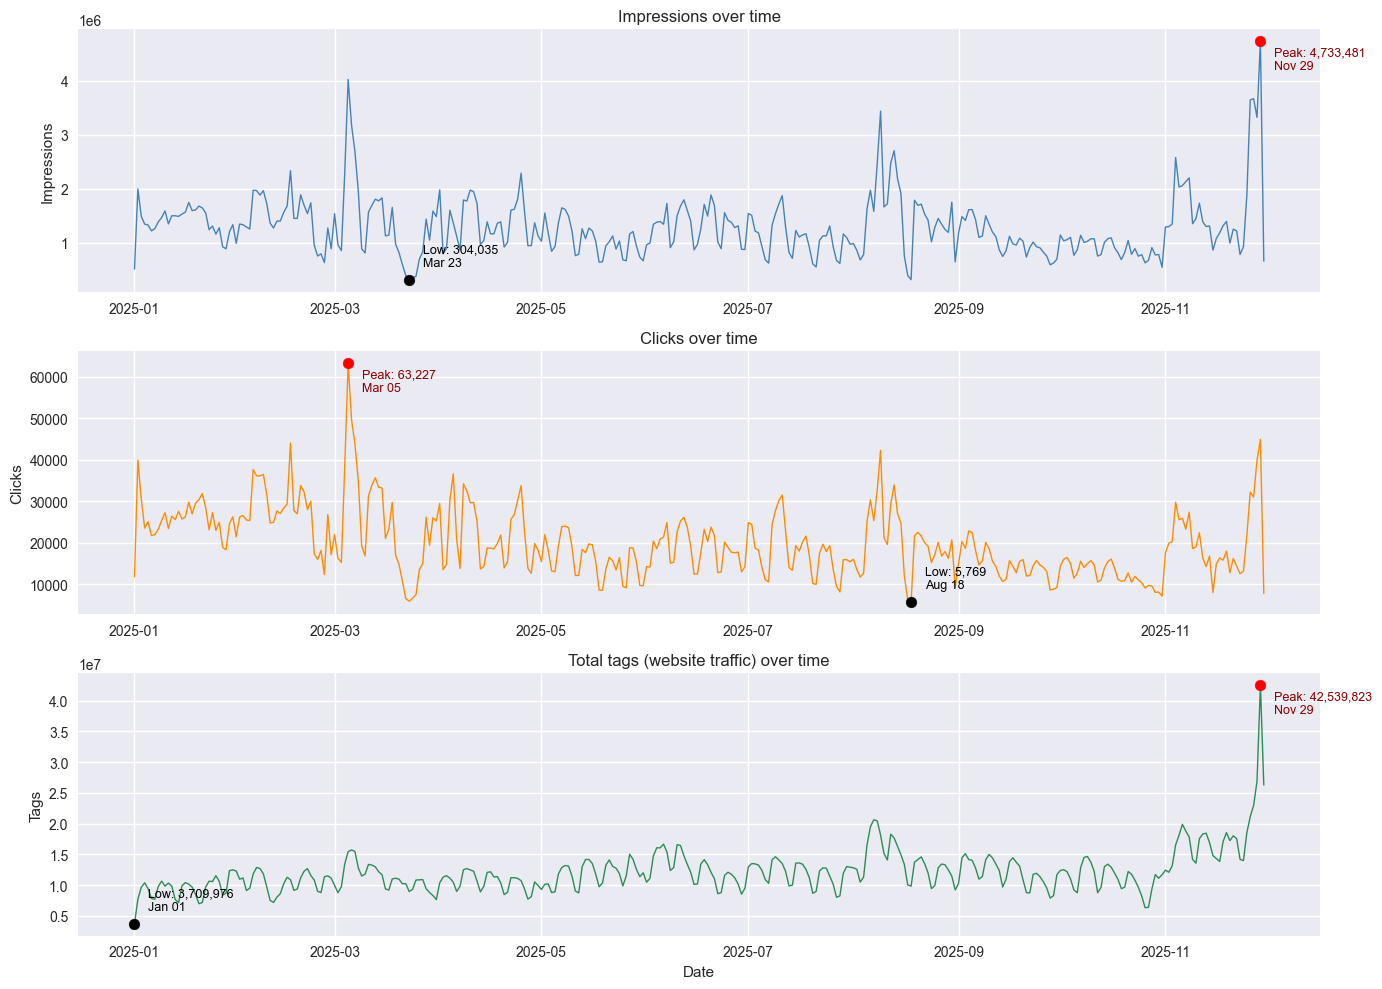

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

metrics = [
    ('imps', 'Impressions over time', 'steelblue', 'Impressions'),
    ('clicks', 'Clicks over time', 'darkorange', 'Clicks'),
    ('total_tags', 'Total tags (website traffic) over time', 'seagreen', 'Tags'),
]

for i, (col, title, color, ylabel) in enumerate(metrics):
    axes[i].plot(df['date'], df[col], color=color, linewidth=1)
    axes[i].set_title(title)
    axes[i].set_ylabel(ylabel)
    
    # marking the peak
    peak_idx = df[col].idxmax()
    peak_date = df.loc[peak_idx, 'date']
    peak_value = df.loc[peak_idx, col]
    axes[i].scatter(peak_date, peak_value, color='red', s=60, zorder=5)
    axes[i].annotate(
        f'Peak: {peak_value:,.0f}\n{peak_date.strftime("%b %d")}',
        xy=(peak_date, peak_value),
        xytext=(10, -20),
        textcoords='offset points',
        fontsize=9,
        color='darkred'
    )
    
    # marking the low
    low_idx = df[col].idxmin()
    low_date = df.loc[low_idx, 'date']
    low_value = df.loc[low_idx, col]
    axes[i].scatter(low_date, low_value, color='black', s=60, zorder=5)
    axes[i].annotate(
        f'Low: {low_value:,.0f}\n{low_date.strftime("%b %d")}',
        xy=(low_date, low_value),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=9,
        color='black'
    )

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.show()



**What the chart reveals:**

The biggest peak for impressions and website traffic happens on November 29. Black 
Friday pushed impressions to 4.7M and total tags to 42.5M, both well above the daily 
averages of 1.3M and 12M. The campaign and the site moved together that day.

Clicks tell a different story. The peak was March 5 (63K), not November. Impressions 
in March were close to peak weeks in November, but November had fewer clicks. Early 
sign that CTR may have dropped during the year.

The impressions low on March 23 also caught my attention: only 304K, against a daily 
average of 1.3M. Looks like a campaign pause or technical issue.

The most important finding is in the bottom chart. Total tags shows a clear upward 
tren






In [41]:
# adding a quarter column to compare all four periods
df['quarter'] = df['date'].dt.to_period('Q')

quarterly = df.groupby('quarter')[['imps', 'clicks', 'total_tags']].mean().round(0)
quarterly



,imps,clicks,total_tags
quarter,,,
2025Q1,1400701.00,25779.00,10319923.00
2025Q2,1247705.00,18903.00,11632210.00
2025Q3,1216369.00,17734.00,12632967.00
2025Q4,1312737.00,16407.00,14565037.00


In [40]:
# calculating the quarter-over-quarter and year-end variation
quarterly = df.groupby('quarter')[['imps', 'clicks', 'total_tags']].mean().round(0)

# variation from Q1 to Q4
variation = {
    'Impressions': (quarterly.loc['2025Q4', 'imps'] / quarterly.loc['2025Q1', 'imps'] - 1) * 100,
    'Clicks': (quarterly.loc['2025Q4', 'clicks'] / quarterly.loc['2025Q1', 'clicks'] - 1) * 100,
    'Total tags': (quarterly.loc['2025Q4', 'total_tags'] / quarterly.loc['2025Q1', 'total_tags'] - 1) * 100,
}

print("Variation Q1 → Q4 (daily averages):")
for metric, value in variation.items():
    print(f"  {metric}: {value:+.1f}%")




Variation Q1 → Q4 (daily averages):
  Impressions: -6.3%
  Clicks: -36.4%
  Total tags: +41.1%


**Quantifying the growth gap:**

Quarterly daily averages give a clearer view than just comparing Q1 and Q4:

| Quarter | Impressions | Clicks | Total Tags |
|---|---|---|---|
| Q1 | 1.4M | 25.8K | 10.3M |
| Q2 | 1.25M | 18.9K | 11.6M |
| Q3 | 1.22M | 17.7K | 12.6M |
| Q4 | 1.31M | 16.4K | 14.6M |

Clicks dropped every quarter, from 25.8K in Q1 to 16.4K in Q4, a 36% decline. Total 
tags went the other way, growing from 10.3M to 14.6M, a 41% increase.

Impressions stayed stable, with only a 6% drop. They followed a "valley" shape, going 
down until Q3 and recovering in Q4, likely from Black Friday investment.

The gap between site growth and campaign engagement is not a sudden change. It's a 
slow drift across every quarter.



**In short:** the site is growing on its own, but the campaign's engagement is shrinking. 
Two trends moving in opposite directions across the year.


### 3.2 CPC - Cost per Click

Looking at how much the campaign paid per click during the year.

In [34]:
# cpc stats
df['cpc'].describe().round(2)

count   334.00
mean      0.15
std       0.04
min       0.07
25%       0.12
50%       0.14
75%       0.17
max       0.50
Name: cpc, dtype: float64

In [35]:
df.groupby('quarter')['cpc'].mean().round(2)


quarter
2025Q1   0.14
2025Q2   0.17
2025Q3   0.14
2025Q4   0.13
Freq: Q-DEC, Name: cpc, dtype: float64

In [36]:
df.groupby('quarter')['cost'].sum().round(2)

quarter
2025Q1   326203.89
2025Q2   293486.00
2025Q3   243270.59
2025Q4   152591.18
Freq: Q-DEC, Name: cost, dtype: float64

In [37]:
df.groupby('quarter')['ctr'].mean().round(2)

quarter
2025Q1   1.87
2025Q2   1.51
2025Q3   1.49
2025Q4   1.31
Freq: Q-DEC, Name: ctr, dtype: float64

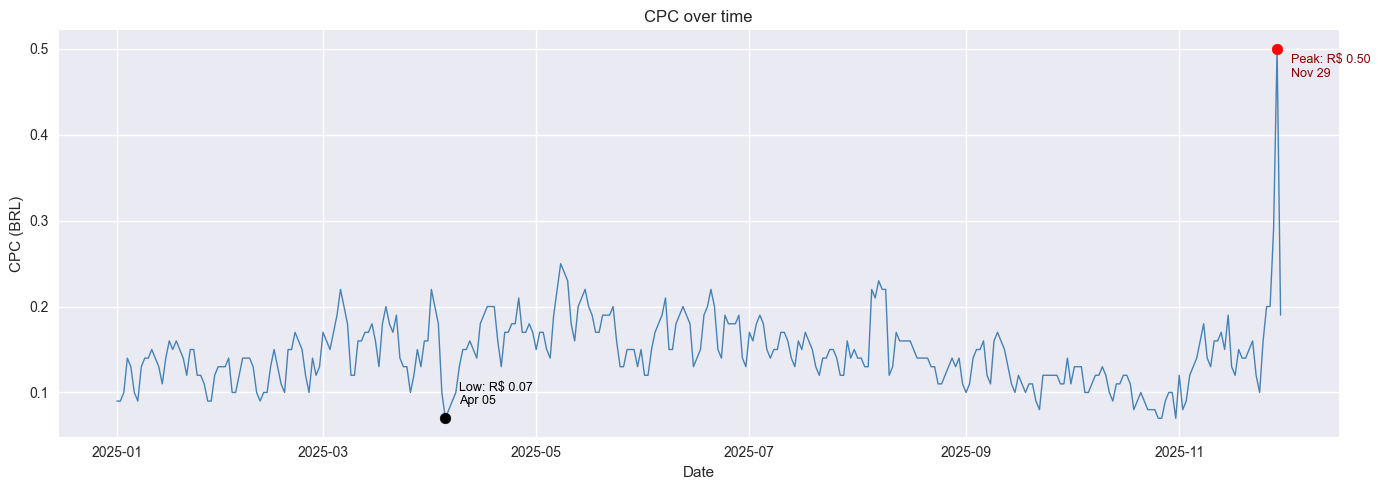

In [38]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['date'], df['cpc'], color='steelblue', linewidth=1)
ax.set_title('CPC over time')
ax.set_ylabel('CPC (BRL)')
ax.set_xlabel('Date')

# marking the peak
peak_idx = df['cpc'].idxmax()
peak_date = df.loc[peak_idx, 'date']
peak_value = df.loc[peak_idx, 'cpc']
ax.scatter(peak_date, peak_value, color='red', s=60, zorder=5)
ax.annotate(
    f'Peak: R$ {peak_value:.2f}\n{peak_date.strftime("%b %d")}',
    xy=(peak_date, peak_value),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=9,
    color='darkred'
)

# marking the low
low_idx = df['cpc'].idxmin()
low_date = df.loc[low_idx, 'date']
low_value = df.loc[low_idx, 'cpc']
ax.scatter(low_date, low_value, color='black', s=60, zorder=5)
ax.annotate(
    f'Low: R$ {low_value:.2f}\n{low_date.strftime("%b %d")}',
    xy=(low_date, low_value),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    color='black'
)

plt.tight_layout()
plt.show()

In [42]:
# variation from Q1 to Q4 for cpc, cost and ctr
variation = {
    'CPC': (df[df['quarter'] == '2025Q4']['cpc'].mean() / df[df['quarter'] == '2025Q1']['cpc'].mean() - 1) * 100,
    'Total cost': (df[df['quarter'] == '2025Q4']['cost'].sum() / df[df['quarter'] == '2025Q1']['cost'].sum() - 1) * 100,
    'CTR': (df[df['quarter'] == '2025Q4']['ctr'].mean() / df[df['quarter'] == '2025Q1']['ctr'].mean() - 1) * 100,
}

print("Variation Q1 → Q4:")
for metric, value in variation.items():
    print(f"  {metric}: {value:+.1f}%")


Variation Q1 → Q4:
  CPC: -4.5%
  Total cost: -53.2%
  CTR: -29.8%


**The takeaway:**

CPC stayed pretty stable during the year. Most days were between R$ 0.10 and R$ 0.20.

The peak on November 29 (R$ 0.50) happened on Black Friday, the same day impressions 
and site traffic hit their highs. Competition for inventory goes up during big retail 
events, pushing CPC higher.

The low on April 5 (R$ 0.07) was the opposite: a day with less competition or cheaper 
inventory. From October on, CPC got more volatile, probably from the Black Friday 
pressure building up.

**Quarterly CPC and total cost:**

| Quarter | CPC | Total Cost |
|---|---|---|
| Q1 |  0.14 |  326,204 |
| Q2 |  0.17 |  293,486 |
| Q3 |  0.14 |  243,271 |
| Q4 |  0.13 |  152,591 |

CPC didn't grow. It dropped 7% from Q1 to Q4. But total cost dropped 53%.

**Quarterly CTR:**

| Quarter | CTR |
|---|---|
| Q1 | 1.87% |
| Q2 | 1.51% |
| Q3 | 1.49% |
| Q4 | 1.31% |

CTR dropped 30% from Q1 to Q4. The lower number of clicks came from two things: less 
investment (fewer impressions bought) and lower engagement.

The drop in clicks wasn't because clicks got more expensive. What changed was the total 
investment, which fell from R$ 326K to R$ 152K. The data doesn't show why. Could be a 
budget cut or something operational. We can confirm the fact, but 
not the reason.




### 3.3 Conversions - RTB and Total

Looking at how conversions behaved during the year



In [43]:

df[['rtb_conversions', 'total_conversions']].describe().round(2)


,rtb_conversions,total_conversions
count,334.00,334.00
mean,162.35,16996.58
std,80.47,5700.76
min,24.00,4752.00
25%,104.25,13693.75
50%,149.50,16439.50
75%,213.75,18896.75
max,578.00,77039.00


In [44]:

df.groupby('quarter')[['rtb_conversions', 'total_conversions']].mean().round(0)

,rtb_conversions,total_conversions
quarter,,
2025Q1,197.00,15582.00
2025Q2,179.00,16474.00
2025Q3,144.00,17047.00
2025Q4,115.00,19786.00


In [45]:
variation = {
    'RTB conversions': (df[df['quarter'] == '2025Q4']['rtb_conversions'].mean() / df[df['quarter'] == '2025Q1']['rtb_conversions'].mean() - 1) * 100,
    'Total conversions': (df[df['quarter'] == '2025Q4']['total_conversions'].mean() / df[df['quarter'] == '2025Q1']['total_conversions'].mean() - 1) * 100,
}

print("Variation Q1 → Q4:")
for metric, value in variation.items():
    print(f"  {metric}: {value:+.1f}%")

Variation Q1 → Q4:
  RTB conversions: -41.8%
  Total conversions: +27.0%


In [47]:
# black friday day metrics vs Q4 average
black_friday = df[df['date'] == '2025-11-29']
q4_avg = df[df['quarter'] == '2025Q4']

print("Black Friday (Nov 29) vs Q4 daily average:")
print(f"  RTB conversions:   {black_friday['rtb_conversions'].values[0]:.0f} vs {q4_avg['rtb_conversions'].mean():.0f}")
print(f"  Total conversions: {black_friday['total_conversions'].values[0]:.0f} vs {q4_avg['total_conversions'].mean():.0f}")

# calculating the multiplier
rtb_mult = black_friday['rtb_conversions'].values[0] / q4_avg['rtb_conversions'].mean()
total_mult = black_friday['total_conversions'].values[0] / q4_avg['total_conversions'].mean()

print(f"\nRTB multiplier:   {rtb_mult:.1f}x")
print(f"Total multiplier: {total_mult:.1f}x")


Black Friday (Nov 29) vs Q4 daily average:
  RTB conversions:   578 vs 115
  Total conversions: 77039 vs 19786

RTB multiplier:   5.0x
Total multiplier: 3.9x


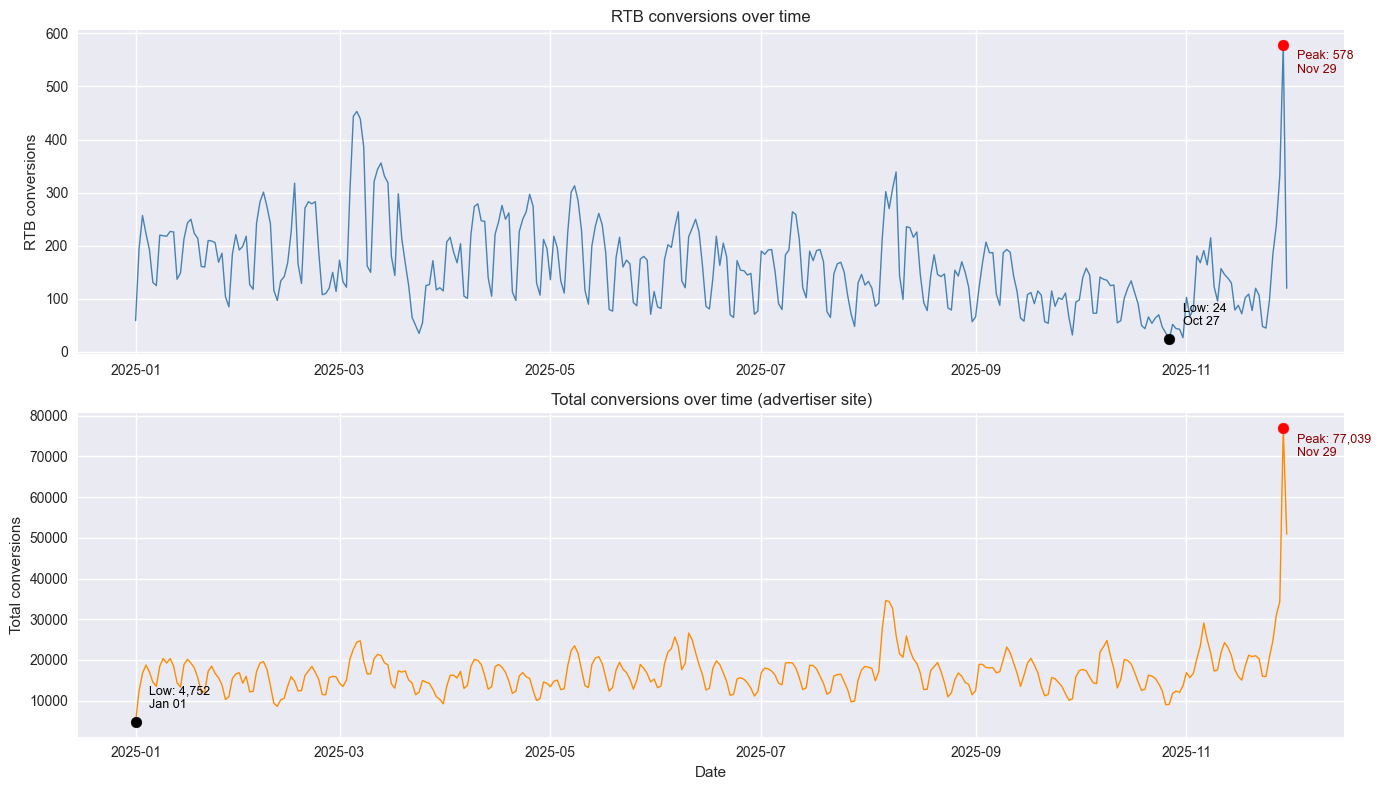

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# rtb conversions
axes[0].plot(df['date'], df['rtb_conversions'], color='steelblue', linewidth=1)
axes[0].set_title('RTB conversions over time')
axes[0].set_ylabel('RTB conversions')

peak_idx = df['rtb_conversions'].idxmax()
peak_date = df.loc[peak_idx, 'date']
peak_value = df.loc[peak_idx, 'rtb_conversions']
axes[0].scatter(peak_date, peak_value, color='red', s=60, zorder=5)
axes[0].annotate(
    f'Peak: {peak_value:.0f}\n{peak_date.strftime("%b %d")}',
    xy=(peak_date, peak_value),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=9,
    color='darkred'
)

low_idx = df['rtb_conversions'].idxmin()
low_date = df.loc[low_idx, 'date']
low_value = df.loc[low_idx, 'rtb_conversions']
axes[0].scatter(low_date, low_value, color='black', s=60, zorder=5)
axes[0].annotate(
    f'Low: {low_value:.0f}\n{low_date.strftime("%b %d")}',
    xy=(low_date, low_value),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    color='black'
)

# total conversions
axes[1].plot(df['date'], df['total_conversions'], color='darkorange', linewidth=1)
axes[1].set_title('Total conversions over time (advertiser site)')
axes[1].set_ylabel('Total conversions')
axes[1].set_xlabel('Date')

peak_idx = df['total_conversions'].idxmax()
peak_date = df.loc[peak_idx, 'date']
peak_value = df.loc[peak_idx, 'total_conversions']
axes[1].scatter(peak_date, peak_value, color='red', s=60, zorder=5)
axes[1].annotate(
    f'Peak: {peak_value:,.0f}\n{peak_date.strftime("%b %d")}',
    xy=(peak_date, peak_value),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=9,
    color='darkred'
)

low_idx = df['total_conversions'].idxmin()
low_date = df.loc[low_idx, 'date']
low_value = df.loc[low_idx, 'total_conversions']
axes[1].scatter(low_date, low_value, color='black', s=60, zorder=5)
axes[1].annotate(
    f'Low: {low_value:,.0f}\n{low_date.strftime("%b %d")}',
    xy=(low_date, low_value),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    color='black'
)

plt.tight_layout()
plt.show()

**The takeaway:**

RTB and total conversions moved in opposite directions, same pattern we saw with 
volume and clicks.

RTB conversions dropped 41.8% from Q1 to Q4 (197 to 115 per day). Total conversions 
grew 27% in the same period (15,582 to 19,786).

The peak on November 29 appears in both charts: 578 RTB conversions and 77,039 total 
conversions. RTB grew 5.0x its Q4 daily average that day, total grew 3.9x.

Black Friday drives strong numbers across every channel, so this peak alone doesn't 
prove the campaign is healthy. It just shows the channel can still scale when 
investment is there.

The low of 24 RTB conversions on October 27 caught my attention. Right before Black 
Friday, RTB was at one of the lowest points of the year. Could be a pause, low 
investment days.

The funnel cascade is now complete:

- Investment dropped 53%
- Impressions dropped 6%
- CTR dropped 30%
- Clicks dropped 36%
- RTB conversions dropped 42%

Each step lost more than the previous one. Meanwhile, the advertiser's site grew 
across every metric. Other traffic sources made up for the RTB drop.

So the advertiser is growing, but RTB is losing space in their channel mix.




### 3.4 RTB Share - How much of the site's conversions come from RTB

Looking at the slice of total site conversions that came specifically from RTB. 




In [48]:


df['share'].describe().round(2)

count   334.00
mean      0.95
std       0.38
min       0.20
25%       0.65
50%       0.94
75%       1.21
max       2.19
Name: share, dtype: float64

In [49]:
df.groupby('quarter')['share'].mean().round(2)


quarter
2025Q1   1.23
2025Q2   1.07
2025Q3   0.82
2025Q4   0.55
Freq: Q-DEC, Name: share, dtype: float64

In [50]:
share_q1 = df[df['quarter'] == '2025Q1']['share'].mean()
share_q4 = df[df['quarter'] == '2025Q4']['share'].mean()
variation = (share_q4 / share_q1 - 1) * 100

print(f"Share Q1: {share_q1:.2f}%")
print(f"Share Q4: {share_q4:.2f}%")
print(f"Variation Q1 → Q4: {variation:+.1f}%")

Share Q1: 1.23%
Share Q4: 0.55%
Variation Q1 → Q4: -55.1%


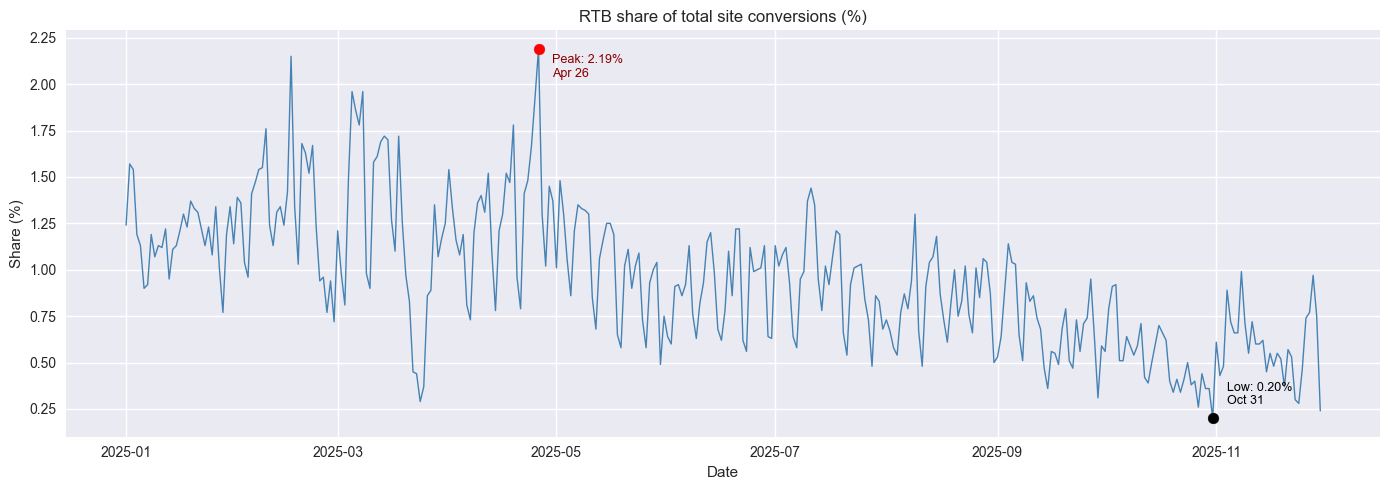

In [51]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['date'], df['share'], color='steelblue', linewidth=1)
ax.set_title('RTB share of total site conversions (%)')
ax.set_ylabel('Share (%)')
ax.set_xlabel('Date')

# marking peak
peak_idx = df['share'].idxmax()
peak_date = df.loc[peak_idx, 'date']
peak_value = df.loc[peak_idx, 'share']
ax.scatter(peak_date, peak_value, color='red', s=60, zorder=5)
ax.annotate(
    f'Peak: {peak_value:.2f}%\n{peak_date.strftime("%b %d")}',
    xy=(peak_date, peak_value),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=9,
    color='darkred'
)

# marking low
low_idx = df['share'].idxmin()
low_date = df.loc[low_idx, 'date']
low_value = df.loc[low_idx, 'share']
ax.scatter(low_date, low_value, color='black', s=60, zorder=5)
ax.annotate(
    f'Low: {low_value:.2f}%\n{low_date.strftime("%b %d")}',
    xy=(low_date, low_value),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    color='black'
)

plt.tight_layout()
plt.show()


**The takeaway:**

RTB share dropped 55.1% over the year, from 1.23% in Q1 to 0.55% in Q4. The decline 
was consistent across all quarters.

The peak of 2.19% on April 26 was a day where RTB performed well and the site had 
lower volume. The low of 0.20% on October 31 was the worst day of the year.

Even with RTB hitting its yearly volume peak on Black Friday (578 conversions), the 
share that day wasn't the highest. The site grew so much that strong RTB days got 
diluted.

Share dropped more than any other metric because the math compounds: RTB conversions 
falling while total conversions grew. Both forces pushing the ratio down.

RTB lost relevance in the advertiser's mix during the year. Not because it stopped 
working, but because it lost weight against everything else.

### 3.5 Overall traffic of the advertiser

The site's traffic showed up in section 3.1 alongside the campaign metrics, where 
we saw it grew 41% from Q1 to Q4 while RTB went the other way. Here the focus is 
different: looking at the site by itself, going deeper into how that growth happened.

The goal is to see if the site grew steadily or with ups and downs, how the RTB 
investment moved alongside it, an

In [52]:
# total_tags by month — daily average and total
df['month'] = df['date'].dt.to_period('M')

monthly_tags = df.groupby('month').agg(
    daily_avg=('total_tags', 'mean'),
    monthly_total=('total_tags', 'sum')
).round(0)

monthly_tags


,daily_avg,monthly_total
month,,
2025-01,9404928.00,291552770
2025-02,10433825.00,292147093
2025-03,11132038.00,345093173
2025-04,10578520.00,317355590
2025-05,11795789.00,365669464
2025-06,12516870.00,375506088
2025-07,11958297.00,370707210
2025-08,13935747.00,432008152
2025-09,11983920.00,359517585


In [53]:
monthly_tags['mom_growth'] = (monthly_tags['daily_avg'].pct_change() * 100).round(1)
monthly_tags


,daily_avg,monthly_total,mom_growth
month,,,
2025-01,9404928.00,291552770,NaN
2025-02,10433825.00,292147093,10.90
2025-03,11132038.00,345093173,6.70
2025-04,10578520.00,317355590,-5.00
2025-05,11795789.00,365669464,11.50
2025-06,12516870.00,375506088,6.10
2025-07,11958297.00,370707210,-4.50
2025-08,13935747.00,432008152,16.50
2025-09,11983920.00,359517585,-14.00


In [55]:
# monthly view: RTB and site metrics side by side

# the goal is to see if RTB drops happened together with site drops or independently
monthly_rtb = df.groupby('month').agg(
    rtb_conv_daily=('rtb_conversions', 'mean'),
    rtb_share=('share', 'mean'),
    rtb_cost=('cost', 'sum'),
    site_tags=('total_tags', 'mean')
).round(2)

# month-over-month growth for both, to compare the trends
monthly_rtb['rtb_conv_growth'] = (monthly_rtb['rtb_conv_daily'].pct_change() * 100).round(1)
monthly_rtb['site_tags_growth'] = (monthly_rtb['site_tags'].pct_change() * 100).round(1)

monthly_rtb

,rtb_conv_daily,rtb_share,rtb_cost,site_tags,rtb_conv_growth,site_tags_growth
month,,,,,,
2025-01,187.35,1.18,100351.16,9404928.06,NaN,NaN
2025-02,193.07,1.31,98644.16,10433824.75,3.10,10.90
2025-03,211.13,1.21,127208.57,11132037.84,9.40,6.70
2025-04,204.07,1.31,104414.92,10578519.67,-3.30,-5.00
2025-05,174.84,1.02,91018.21,11795789.16,-14.30,11.50
2025-06,156.93,0.89,98052.87,12516869.60,-10.20,6.10
2025-07,152.58,0.95,86485.79,11958297.10,-2.80,-4.50
2025-08,163.06,0.84,99989.72,13935746.84,6.90,16.50
2025-09,114.27,0.69,56795.08,11983919.50,-29.90,-14.00


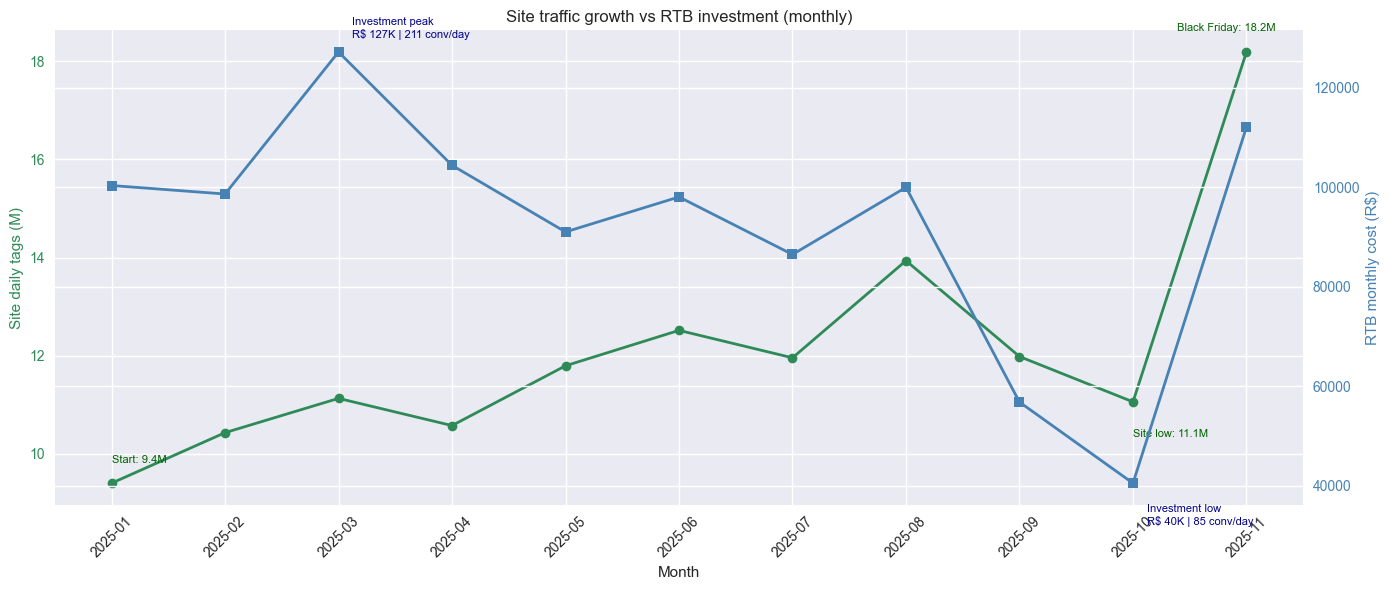

In [57]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# left axis: site tags (in millions)
color_site = 'seagreen'
ax1.set_xlabel('Month')
ax1.set_ylabel('Site daily tags (M)', color=color_site)
ax1.plot(monthly_rtb.index.astype(str), monthly_rtb['site_tags'] / 1_000_000, 
         color=color_site, linewidth=2, marker='o', label='Site tags')
ax1.tick_params(axis='y', labelcolor=color_site)
ax1.tick_params(axis='x', rotation=45)

# annotations on site line
ax1.annotate('Start: 9.4M',
             xy=('2025-01', 9.4), xytext=(0, 15),
             textcoords='offset points', fontsize=8, color='darkgreen')

ax1.annotate('Site low: 11.1M',
             xy=('2025-10', 11.06), xytext=(0, -25),
             textcoords='offset points', fontsize=8, color='darkgreen')

ax1.annotate('Black Friday: 18.2M',
             xy=('2025-11', 18.19), xytext=(-50, 15),
             textcoords='offset points', fontsize=8, color='darkgreen')

# right axis: rtb cost
ax2 = ax1.twinx()
color_rtb = 'steelblue'
ax2.set_ylabel('RTB monthly cost (R$)', color=color_rtb)
ax2.plot(monthly_rtb.index.astype(str), monthly_rtb['rtb_cost'], 
         color=color_rtb, linewidth=2, marker='s', label='RTB cost')
ax2.tick_params(axis='y', labelcolor=color_rtb)

# annotations on rtb cost line
ax2.annotate('Investment peak\nR$ 127K | 211 conv/day',
             xy=('2025-03', 127208), xytext=(10, 10),
             textcoords='offset points', fontsize=8, color='darkblue')

ax2.annotate('Investment low\nR$ 40K | 85 conv/day',
             xy=('2025-10', 40484), xytext=(10, -30),
             textcoords='offset points', fontsize=8, color='darkblue')

plt.title('Site traffic growth vs RTB investment (monthly)')
fig.tight_layout()
plt.show()


In [58]:
monthly_rtb['rtb_conv_value'] = df.groupby('month')['rtb_conversion_value'].sum().values
monthly_rtb['roas'] = (monthly_rtb['rtb_conv_value'] / monthly_rtb['rtb_cost']).round(2)

monthly_rtb[['rtb_cost', 'rtb_conv_value', 'roas']]




,rtb_cost,rtb_conv_value,roas
month,,,
2025-01,100351.16,1609272.78,16.04
2025-02,98644.16,1516631.51,15.37
2025-03,127208.57,1859982.72,14.62
2025-04,104414.92,1794958.53,17.19
2025-05,91018.21,1677748.38,18.43
2025-06,98052.87,1408403.49,14.36
2025-07,86485.79,1445280.60,16.71
2025-08,99989.72,1498998.82,14.99
2025-09,56795.08,1070499.94,18.85


In [59]:
# ROAS variation across the year
roas_q1 = df[df['quarter'] == '2025Q1']['roas'].mean()
roas_q4 = df[df['quarter'] == '2025Q4']['roas'].mean()
variation = (roas_q4 / roas_q1 - 1) * 100

print(f"ROAS Q1: {roas_q1:.2f}")
print(f"ROAS Q4: {roas_q4:.2f}")
print(f"Variation Q1 → Q4: {variation:+.1f}%")

ROAS Q1: 15.85
ROAS Q4: 15.51
Variation Q1 → Q4: -2.2%


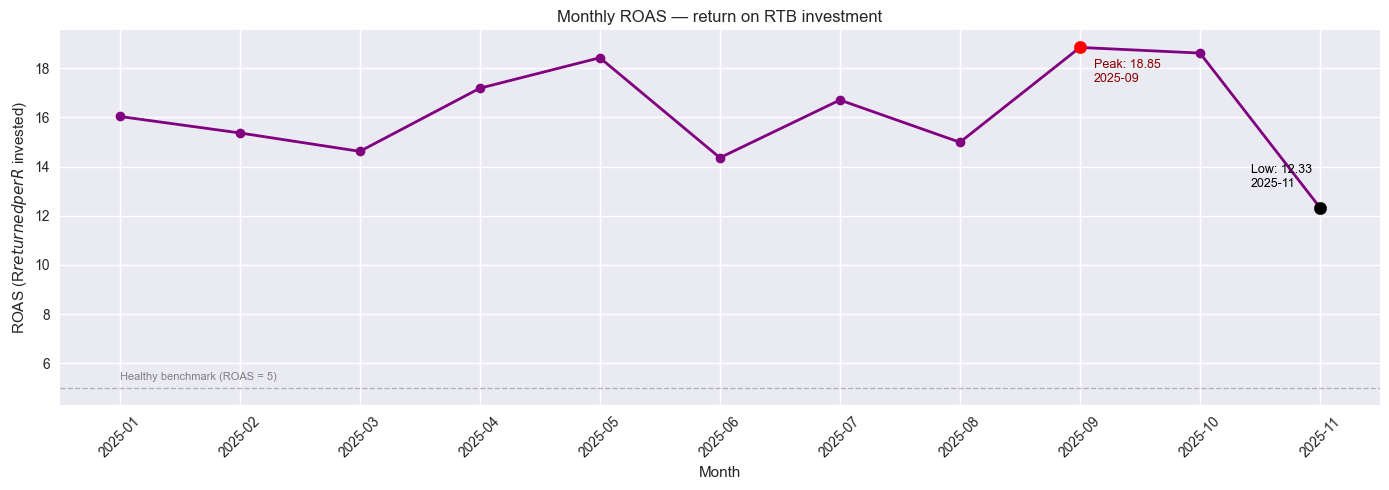

In [60]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_rtb.index.astype(str), monthly_rtb['roas'], 
        color='purple', linewidth=2, marker='o')
ax.set_title('Monthly ROAS — return on RTB investment')
ax.set_ylabel('ROAS (R$ returned per R$ invested)')
ax.set_xlabel('Month')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.text('2025-01', 5.3, 'Healthy benchmark (ROAS = 5)', fontsize=8, color='gray')

# annotating peak and low
peak_month = monthly_rtb['roas'].idxmax()
peak_value = monthly_rtb['roas'].max()
ax.scatter(str(peak_month), peak_value, color='red', s=80, zorder=5)
ax.annotate(f'Peak: {peak_value:.2f}\n{peak_month}',
            xy=(str(peak_month), peak_value),
            xytext=(10, -25),
            textcoords='offset points',
            fontsize=9, color='darkred')

low_month = monthly_rtb['roas'].idxmin()
low_value = monthly_rtb['roas'].min()
ax.scatter(str(low_month), low_value, color='black', s=80, zorder=5)
ax.annotate(f'Low: {low_value:.2f}\n{low_month}',
            xy=(str(low_month), low_value),
            xytext=(-50, 15),
            textcoords='offset points',
            fontsize=9, color='black')

plt.tight_layout()
plt.show()



In [61]:
# validating ROAS calculation
# showing all the values used in the math for transparency

print("Monthly ROAS validation:\n")
print(f"{'Month':<10} {'Cost (R$)':>15} {'Conv Value (R$)':>20} {'ROAS':>10}")
print("-" * 60)

for month in monthly_rtb.index:
    cost = monthly_rtb.loc[month, 'rtb_cost']
    value = monthly_rtb.loc[month, 'rtb_conv_value']
    roas = monthly_rtb.loc[month, 'roas']
    print(f"{str(month):<10} {cost:>15,.2f} {value:>20,.2f} {roas:>10.2f}")

print("\nDouble-check: ROAS should equal Conv Value / Cost")
print(f"Example for January: {monthly_rtb.loc['2025-01', 'rtb_conv_value']:,.2f} / {monthly_rtb.loc['2025-01', 'rtb_cost']:,.2f} = {monthly_rtb.loc['2025-01', 'rtb_conv_value'] / monthly_rtb.loc['2025-01', 'rtb_cost']:.2f}")

Monthly ROAS validation:

Month            Cost (R$)      Conv Value (R$)       ROAS
------------------------------------------------------------
2025-01         100,351.16         1,609,272.78      16.04
2025-02          98,644.16         1,516,631.51      15.37
2025-03         127,208.57         1,859,982.72      14.62
2025-04         104,414.92         1,794,958.53      17.19
2025-05          91,018.21         1,677,748.38      18.43
2025-06          98,052.87         1,408,403.49      14.36
2025-07          86,485.79         1,445,280.60      16.71
2025-08          99,989.72         1,498,998.82      14.99
2025-09          56,795.08         1,070,499.94      18.85
2025-10          40,484.44           753,641.74      18.62
2025-11         112,106.75         1,382,176.92      12.33

Double-check: ROAS should equal Conv Value / Cost
Example for January: 1,609,272.78 / 100,351.16 = 16.04


**The takeaway:**

The site grew 41% during the year, from 9.4M daily tags in January to 18.2M in November. 
The growth wasn't smooth: 4 of the 11 months had negative growth, with September (-14%) 
and October (-7.7%) as the worst. November jumped 64%, driven by Black Friday.

The chart shows the site and RTB investment going in opposite directions. In the first 
months, the investment was high (R$ 100-127K) while the site was small (9-11M tags). 
From May on, the investment started dropping while the site kept growing.

This raised a question: did the investment cut hurt the channel's efficiency? The 
ROAS data answered it.

**Quarterly ROAS:**

| Quarter | ROAS |
|---|---|
| Q1 | 15.85 |
| Q4 | 15.51 |

Only -2.2% variation. Every volume metric dropped between 30% and 55%, but ROAS stayed 
stable. Each  1 invested kept returning around  15 throughout the year.

The lowest ROAS was November (12.33), when Black Friday pushed CPC up. The highest was 
September (18.85), one of the lowest investment months.

So the volume drop wasn't a performance issue. The channel kept its efficiency even 
with the investment falling by more than half. This is a healthy ROAS in general market 
references, though a full evaluation would depend on the client's internal benchmarks.

The site grew on its own, the RTB investment was reduced, but the channel kept 
delivering. The drop in RTB volume reflects a strategic decision, not a loss of 
performance.





### 3.6 Seasonality and Stability

Two questions from the brief still need a direct answer: is there any seasonality 
in the data, and is RTB's delivery stable? 


In [66]:

# adding day of week column
df['weekday'] = df['date'].dt.day_name()

# defining the order so the table appears in week order, not alphabetical
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# weekly seasonality across the main metrics
weekly_pattern = df.groupby('weekday').agg(
    imps=('imps', 'mean'),
    clicks=('clicks', 'mean'),
    rtb_conversions=('rtb_conversions', 'mean'),
    total_conversions=('total_conversions', 'mean'),
    total_tags=('total_tags', 'mean'),
    share=('share', 'mean'),
    roas=('roas', 'mean')
).round(2).reindex(weekday_order)

weekly_pattern

,imps,clicks,rtb_conversions,total_conversions,total_tags,share,roas
weekday,,,,,,,
Monday,972826.79,15314.11,90.47,13458.57,9850455.49,0.69,15.02
Tuesday,1393035.98,21297.87,162.26,17326.23,12539171.96,0.95,16.43
Wednesday,1437591.50,22022.75,188.40,18766.94,13298334.75,1.01,17.40
Thursday,1433957.25,22047.58,194.92,19062.50,13289148.44,1.03,16.81
Friday,1441757.88,22414.65,194.73,18276.00,12956412.06,1.07,16.44
Saturday,1388444.69,20882.90,188.29,17601.19,12383375.31,1.09,17.14
Sunday,973073.62,15795.31,115.90,14417.77,10275059.92,0.83,17.18


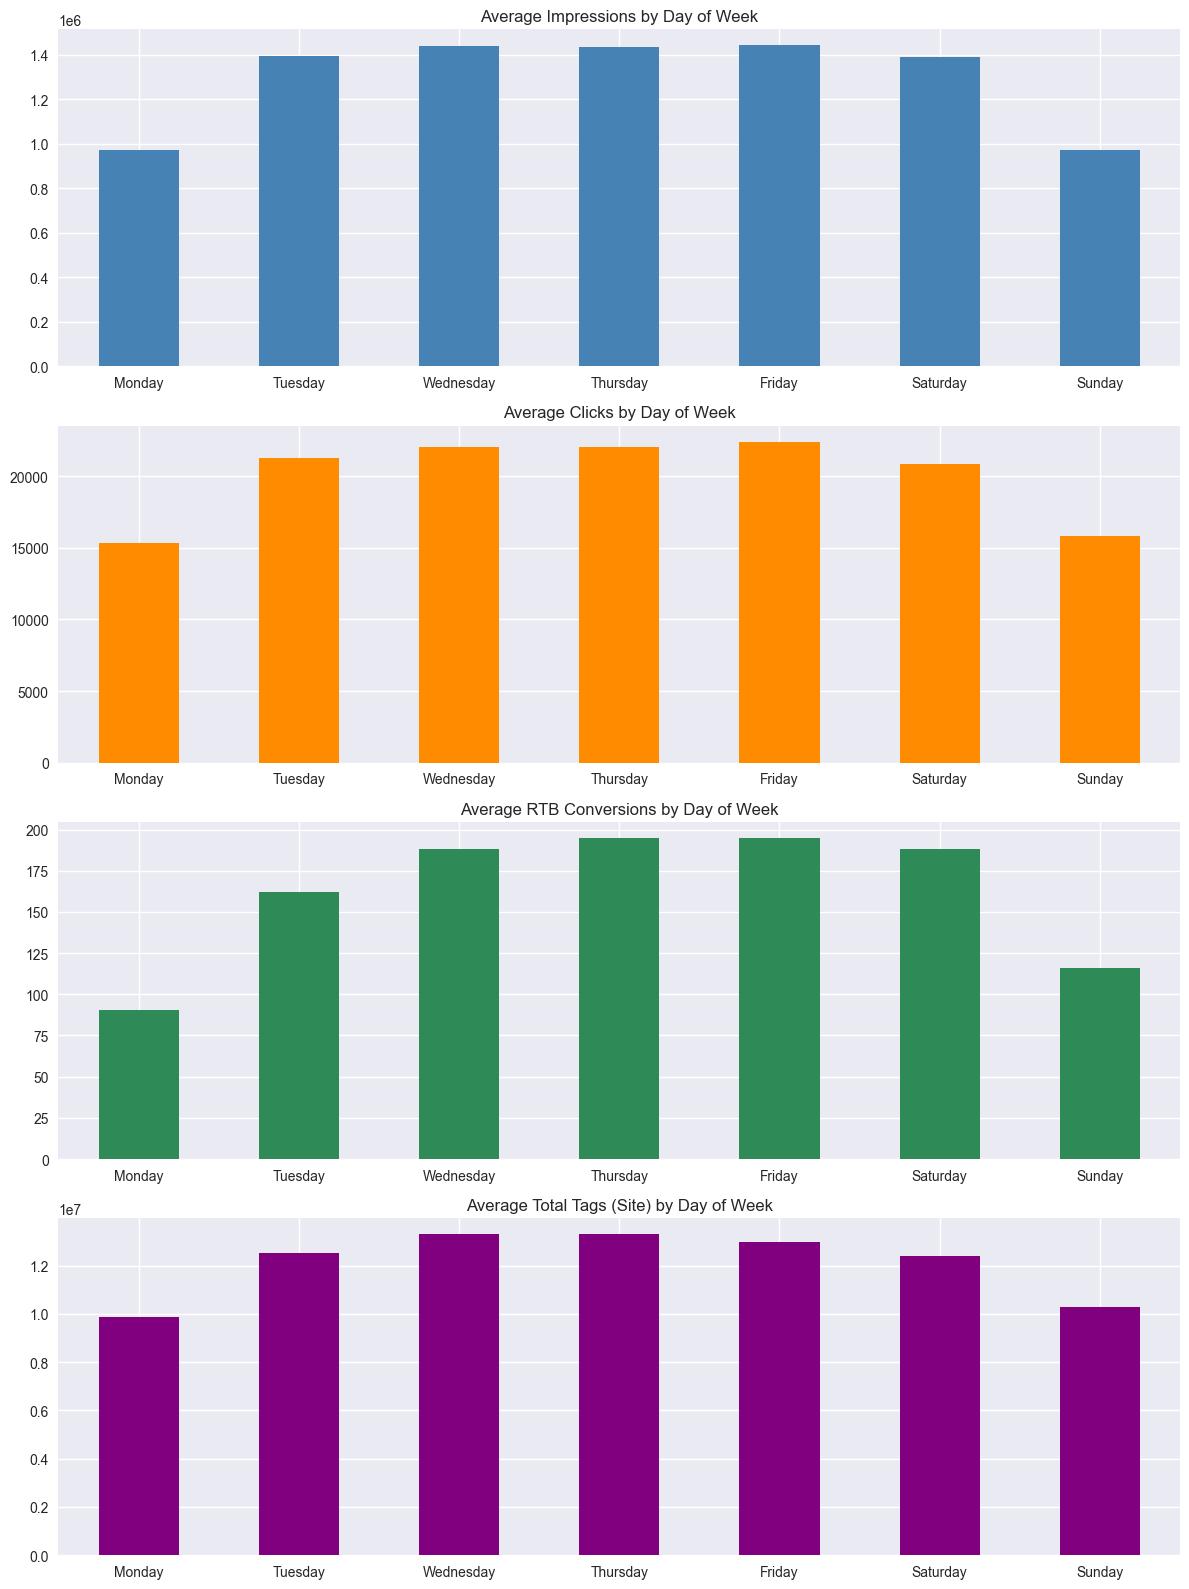

In [69]:
# weekly seasonality visualized — bar chart for the main volume metrics


# the goal is to make the weekly pattern visible at a glance

fig, axes = plt.subplots(4, 1, figsize=(12, 16))

# defining the metrics, titles, axes and colors for each subplot
metrics_to_plot = [
    ('imps', 'Impressions', axes[0], 'steelblue'),
    ('clicks', 'Clicks', axes[1], 'darkorange'),
    ('rtb_conversions', 'RTB Conversions', axes[2], 'seagreen'),
    ('total_tags', 'Total Tags (Site)', axes[3], 'purple')
]

# looping through each metric to plot it on the right subplot
for col, title, ax, color in metrics_to_plot:
    weekly_pattern[col].plot(kind='bar', ax=ax, color=color)
    ax.set_title(f'Average {title} by Day of Week')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)  # horizontal labels since we have more space

plt.tight_layout()
plt.show()



In [70]:
# calculating the weekday volume gap

# comparing the weakest day to the peak day for each metric

for col, label in [('imps', 'Impressions'), ('clicks', 'Clicks'), 
                   ('rtb_conversions', 'RTB Conversions'), 
                   ('total_tags', 'Total Tags')]:
    peak = weekly_pattern[col].max()
    low = weekly_pattern[col].min()
    drop_pct = ((peak - low) / peak * 100).round(1)
    peak_day = weekly_pattern[col].idxmax()
    low_day = weekly_pattern[col].idxmin()
    print(f"{label}: peak {peak:,.0f} ({peak_day}) vs low {low:,.0f} ({low_day}) = {drop_pct}% drop")


Impressions: peak 1,441,758 (Friday) vs low 972,827 (Monday) = 32.5% drop
Clicks: peak 22,415 (Friday) vs low 15,314 (Monday) = 31.7% drop
RTB Conversions: peak 195 (Thursday) vs low 90 (Monday) = 53.6% drop
Total Tags: peak 13,298,335 (Wednesday) vs low 9,850,455 (Monday) = 25.9% drop


**The weekly pattern is clear and consistent.**

Monday is the weakest day across every metric:

- Impressions: -32.5% vs Friday (peak)
- Clicks: -31.7% vs Friday (peak)
- RTB Conversions: -53.6% vs Thursday (peak)
- Total Tags: -25.9% vs Wednesday (peak)

Sunday follows a similar pattern. The same shape appears across RTB metrics and site 
tags, so it's not specific to the channel. It reflects how users behave on the site.

The drop in RTB conversions on Monday (-53.6%) is much bigger than the drop in site 
tags (-25.9%). Slow days on the site hurt the channel even more. ROAS, however, stays 
stable across the week (15-17). Efficiency doesn't depend on the day.


In [71]:
# coefficient of variation for each metric

# CV = std / mean * 100
# lower CV means more stable, higher CV means more volatile
metrics_to_check = ['imps', 'clicks', 'cost', 'cpc', 'rtb_conversions', 
                    'total_conversions', 'total_tags', 'share', 'roas']

cv_overall = pd.DataFrame({
    'metric': metrics_to_check,
    'mean': [df[m].mean() for m in metrics_to_check],
    'std': [df[m].std() for m in metrics_to_check],
    'cv (%)': [(df[m].std() / df[m].mean() * 100) for m in metrics_to_check]
}).round(2)

cv_overall.sort_values('cv (%)')




,metric,mean,std,cv (%)
8,roas,16.64,4.28,25.70
3,cpc,0.15,0.04,27.88
6,total_tags,12089893.27,3454784.48,28.58
5,total_conversions,16996.58,5700.76,33.54
7,share,0.95,0.38,39.43
1,clicks,19977.83,8245.59,41.27
0,imps,1292177.09,563058.12,43.57
4,rtb_conversions,162.35,80.47,49.57
2,cost,3040.57,1982.42,65.20


In [72]:
# coefficient of variation by quarter

# checking if stability changed across the year
cv_by_quarter = df.groupby('quarter').agg({
    'imps': lambda x: x.std() / x.mean() * 100,
    'clicks': lambda x: x.std() / x.mean() * 100,
    'rtb_conversions': lambda x: x.std() / x.mean() * 100,
    'roas': lambda x: x.std() / x.mean() * 100,
    'cpc': lambda x: x.std() / x.mean() * 100,
    'share': lambda x: x.std() / x.mean() * 100
}).round(2)

cv_by_quarter.columns = [f'{c}_cv' for c in cv_by_quarter.columns]
cv_by_quarter

,imps_cv,clicks_cv,rtb_conversions_cv,roas_cv,cpc_cv,share_cv
quarter,,,,,,
2025Q1,40.41,35.86,44.70,21.45,20.89,28.29
2025Q2,29.39,32.49,37.10,20.11,20.25,30.17
2025Q3,42.42,36.92,43.62,21.92,20.32,28.94
2025Q4,61.36,45.65,71.81,40.54,47.04,32.87


In [73]:
# checking how much black friday distorts Q4 stability

# excluding nov 29 to see the underlying Q4 stability

q4_no_bf = df[(df['quarter'] == '2025Q4') & (df['date'] != '2025-11-29')]
q4_with_bf = df[df['quarter'] == '2025Q4']

print("Q4 ROAS CV (with Black Friday):", round(q4_with_bf['roas'].std() / q4_with_bf['roas'].mean() * 100, 2), "%")
print("Q4 ROAS CV (without Black Friday):", round(q4_no_bf['roas'].std() / q4_no_bf['roas'].mean() * 100, 2), "%")

print("\nQ4 CPC CV (with Black Friday):", round(q4_with_bf['cpc'].std() / q4_with_bf['cpc'].mean() * 100, 2), "%")
print("Q4 CPC CV (without Black Friday):", round(q4_no_bf['cpc'].std() / q4_no_bf['cpc'].mean() * 100, 2), "%")

print("\nQ4 RTB Conversions CV (with Black Friday):", round(q4_with_bf['rtb_conversions'].std() / q4_with_bf['rtb_conversions'].mean() * 100, 2), "%")
print("Q4 RTB Conversions CV (without Black Friday):", round(q4_no_bf['rtb_conversions'].std() / q4_no_bf['rtb_conversions'].mean() * 100, 2), "%")



Q4 ROAS CV (with Black Friday): 40.54 %
Q4 ROAS CV (without Black Friday): 40.11 %

Q4 CPC CV (with Black Friday): 47.04 %
Q4 CPC CV (without Black Friday): 31.48 %

Q4 RTB Conversions CV (with Black Friday): 71.81 %
Q4 RTB Conversions CV (without Black Friday): 52.94 %


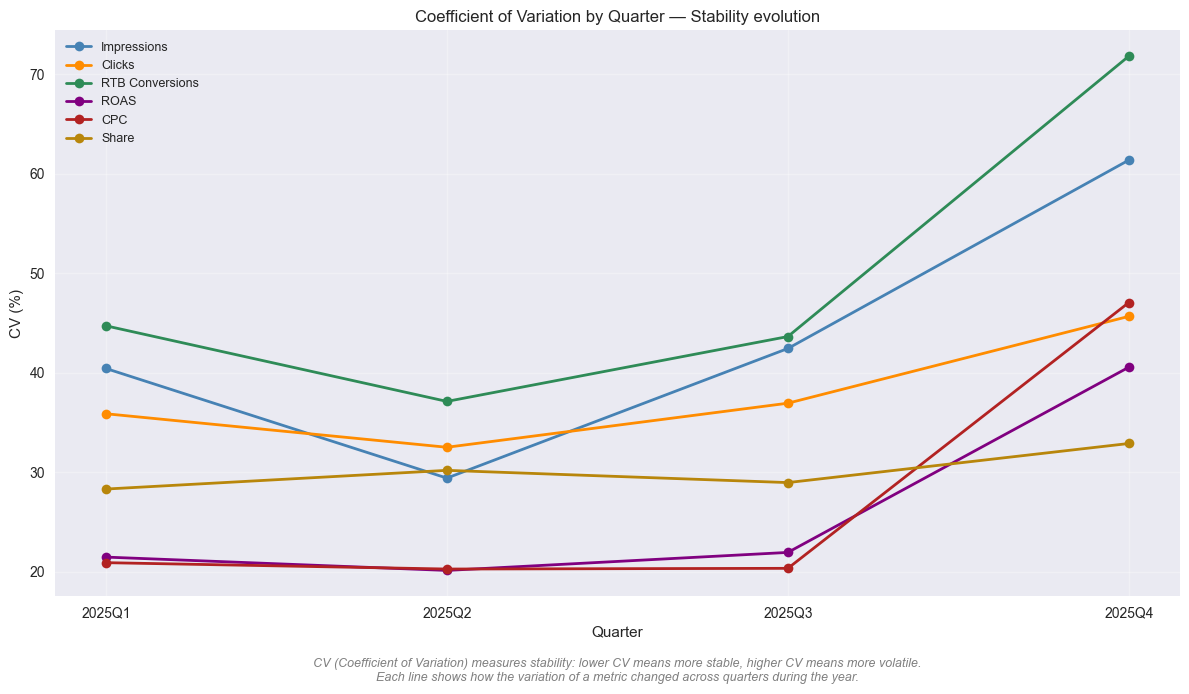

In [82]:
# CV by quarter — visual comparison of stability evolution across the year
# the goal is to show that volatility jumped in Q4

fig, ax = plt.subplots(figsize=(12, 7))

# plotting each metric as a line across quarters
metrics_to_plot = {
    'imps_cv': ('Impressions', 'steelblue'),
    'clicks_cv': ('Clicks', 'darkorange'),
    'rtb_conversions_cv': ('RTB Conversions', 'seagreen'),
    'roas_cv': ('ROAS', 'purple'),
    'cpc_cv': ('CPC', 'firebrick'),
    'share_cv': ('Share', 'darkgoldenrod')
}

for col, (label, color) in metrics_to_plot.items():
    ax.plot(cv_by_quarter.index.astype(str), cv_by_quarter[col], 
            marker='o', linewidth=2, label=label, color=color)

ax.set_title('Coefficient of Variation by Quarter — Stability evolution')
ax.set_xlabel('Quarter')
ax.set_ylabel('CV (%)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# adding explanation at the bottom
ax.text(0.5, -0.15, 
        'CV (Coefficient of Variation) measures stability: lower CV means more stable, higher CV means more volatile.\n'
        'Each line shows how the variation of a metric changed across quarters during the year.',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

In [83]:
# AOV by quarter
aov_quarterly = df.groupby('quarter')['aov'].mean().round(2)

# AOV variation
aov_q1 = df[df['quarter'] == '2025Q1']['aov'].mean()
aov_q4 = df[df['quarter'] == '2025Q4']['aov'].mean()
aov_variation = (aov_q4 / aov_q1 - 1) * 100

print("AOV by quarter:")
print(aov_quarterly)
print(f"\nVariation Q1 → Q4: {aov_variation:+.1f}%")

AOV by quarter:
quarter
2025Q1   282.24
2025Q2   302.97
2025Q3   309.32
2025Q4   290.43
Freq: Q-DEC, Name: aov, dtype: float64

Variation Q1 → Q4: +2.9%


In [84]:
# correlation between CTR drop and investment drop
ctr_invest = df.groupby('month').agg(
    ctr=('ctr', 'mean'),
    cost=('cost', 'sum')
).round(2)

# pearson correlation between ctr and cost
correlation = ctr_invest['ctr'].corr(ctr_invest['cost'])

print("CTR vs Investment per month:")
print(ctr_invest)
print(f"\nCorrelation between CTR and Cost: {correlation:.2f}")



CTR vs Investment per month:
         ctr      cost
month                 
2025-01 1.87 100351.16
2025-02 1.92  98644.16
2025-03 1.82 127208.57
2025-04 1.61 104414.92
2025-05 1.50  91018.21
2025-06 1.43  98052.87
2025-07 1.64  86485.79
2025-08 1.41  99989.72
2025-09 1.43  56795.08
2025-10 1.38  40484.44
2025-11 1.24 112106.75

Correlation between CTR and Cost: 0.36


In [85]:
# correlations: investment and site traffic vs RTB conversions
monthly_corr = df.groupby('month').agg(
    cost=('cost', 'sum'),
    rtb_conv=('rtb_conversions', 'sum'),
    site_tags=('total_tags', 'sum')
)

corr_invest_conv = monthly_corr['cost'].corr(monthly_corr['rtb_conv'])
corr_tags_conv = monthly_corr['site_tags'].corr(monthly_corr['rtb_conv'])

print(f"Correlation between Investment and RTB Conversions: {corr_invest_conv:.2f}")
print(f"Correlation between Site Tags and RTB Conversions:  {corr_tags_conv:.2f}")




Correlation between Investment and RTB Conversions: 0.86
Correlation between Site Tags and RTB Conversions:  -0.28


In [86]:
corr_invest_roas = monthly_corr['cost'].corr(df.groupby('month')['roas'].mean())
print(f"Correlation between Investment and ROAS: {corr_invest_roas:.2f}")

Correlation between Investment and ROAS: -0.47


In [87]:
# CTR variation Q1 → Q4
ctr_q1 = df[df['quarter'] == '2025Q1']['ctr'].mean()
ctr_q4 = df[df['quarter'] == '2025Q4']['ctr'].mean()
ctr_variation = (ctr_q4 / ctr_q1 - 1) * 100

print(f"CTR Q1: {ctr_q1:.2f}%")
print(f"CTR Q4: {ctr_q4:.2f}%")
print(f"Variation Q1 → Q4: {ctr_variation:+.1f}%")

CTR Q1: 1.87%
CTR Q4: 1.31%
Variation Q1 → Q4: -29.8%


In [88]:
# top 10 days for the main metrics
# the goal is to spot any seasonal event beyond Black Friday

print("=== TOP 10 days — RTB Conversions ===")
print(df.nlargest(10, 'rtb_conversions')[['date', 'rtb_conversions', 'imps', 'clicks']].to_string(index=False))

print("\n=== TOP 10 days — Total Conversions (Site) ===")
print(df.nlargest(10, 'total_conversions')[['date', 'total_conversions', 'total_tags']].to_string(index=False))

print("\n=== TOP 10 days — Total Tags (Site Traffic) ===")
print(df.nlargest(10, 'total_tags')[['date', 'total_tags', 'total_conversions']].to_string(index=False))



=== TOP 10 days — RTB Conversions ===
      date  rtb_conversions    imps  clicks
2025-11-29              578 4733481   44896
2025-03-06              453 3181574   49603
2025-03-05              444 4026871   63227
2025-03-07              439 2689018   43839
2025-03-08              386 1951646   34877
2025-03-13              356 1806381   35646
2025-03-12              344 1689611   33911
2025-08-09              339 3438554   42263
2025-11-28              332 3323024   39881
2025-03-14              331 1774799   33393

=== TOP 10 days — Total Conversions (Site) ===
      date  total_conversions  total_tags
2025-11-29              77039    42539823
2025-11-30              50919    26273586
2025-08-06              34578    19484317
2025-08-07              34345    20622589
2025-11-28              34328    26878304
2025-08-08              32649    20453196
2025-11-27              31014    22964802
2025-11-06              29087    19882765
2025-08-05              27614    16525282
2025-06-10

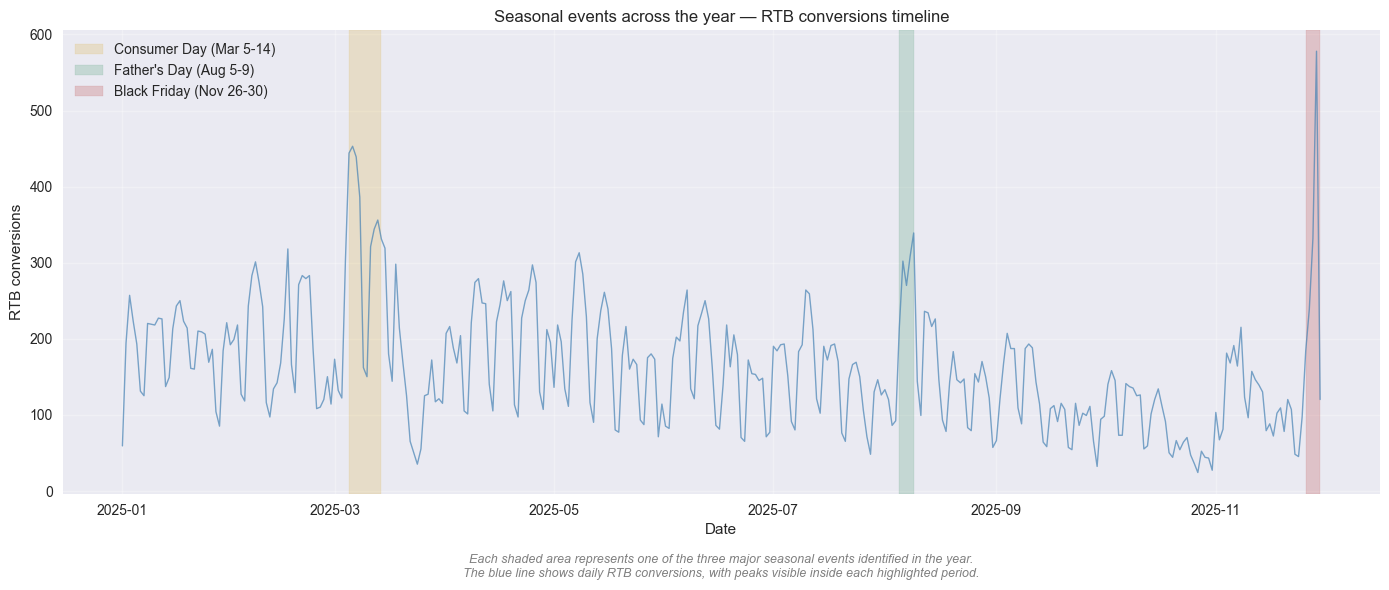

In [89]:

# seasonal events visualized on the RTB conversions timeline
# the goal is to highlight the three major events identified in the data

fig, ax = plt.subplots(figsize=(14, 6))

# main line: RTB conversions over time
ax.plot(df['date'], df['rtb_conversions'], color='steelblue', linewidth=1, alpha=0.7)
ax.set_title('Seasonal events across the year — RTB conversions timeline')
ax.set_ylabel('RTB conversions')
ax.set_xlabel('Date')

# highlighting the three seasonal events with shaded areas

# Consumer Day window (March 5-14)
ax.axvspan(pd.Timestamp('2025-03-05'), pd.Timestamp('2025-03-14'), 
           alpha=0.2, color='goldenrod', label='Consumer Day (Mar 5-14)')

# Father's Day week (August 5-9)
ax.axvspan(pd.Timestamp('2025-08-05'), pd.Timestamp('2025-08-09'), 
           alpha=0.2, color='seagreen', label="Father's Day (Aug 5-9)")

# Black Friday / Cyber Week (November 26-30)
ax.axvspan(pd.Timestamp('2025-11-26'), pd.Timestamp('2025-11-30'), 
           alpha=0.2, color='firebrick', label='Black Friday (Nov 26-30)')

ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# adding explanation at the bottom
ax.text(0.5, -0.18, 
        'Each shaded area represents one of the three major seasonal events identified in the year.\n'
        'The blue line shows daily RTB conversions, with peaks visible inside each highlighted period.',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()



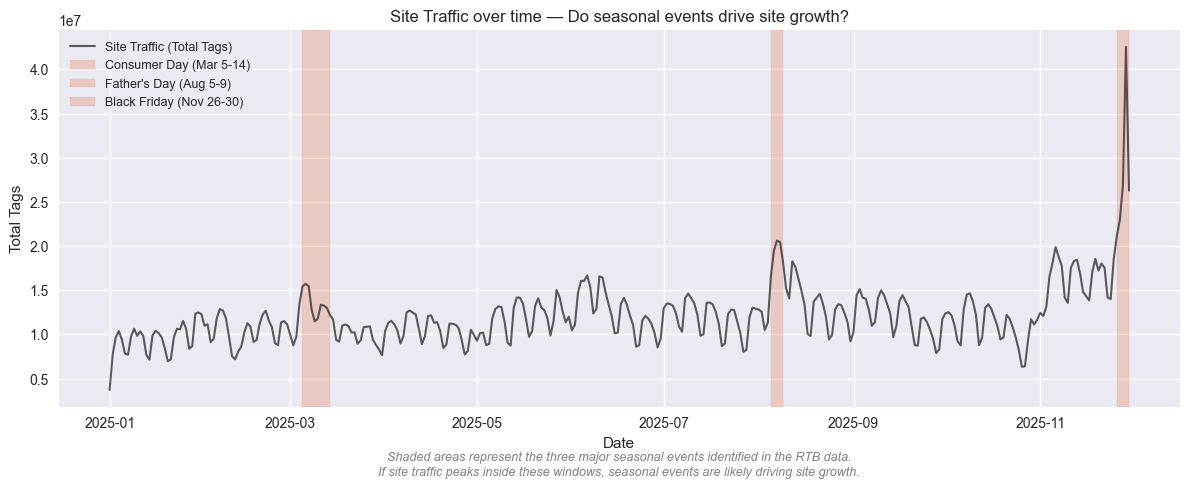

In [92]:
fig, ax = plt.subplots(figsize=(12, 5))

# site traffic ao longo do tempo
ax.plot(df['date'], df['total_tags'], color='#1A1A1A', linewidth=1.5, alpha=0.7, label='Site Traffic (Total Tags)')

# destacando os 3 eventos sazonais
ax.axvspan(pd.Timestamp('2025-03-05'), pd.Timestamp('2025-03-14'),
           alpha=0.2, color='#E8450A', label='Consumer Day (Mar 5-14)')

ax.axvspan(pd.Timestamp('2025-08-05'), pd.Timestamp('2025-08-09'),
           alpha=0.2, color='#E8450A', label="Father's Day (Aug 5-9)")

ax.axvspan(pd.Timestamp('2025-11-26'), pd.Timestamp('2025-11-30'),
           alpha=0.2, color='#E8450A', label='Black Friday (Nov 26-30)')

ax.set_title("Site Traffic over time — Do seasonal events drive site growth?")
ax.set_ylabel('Total Tags')
ax.set_xlabel('Date')

ax.legend(loc='upper left', fontsize=9)

# legenda explicativa embaixo do grafico
ax.text(0.5, -0.18,
        'Shaded areas represent the three major seasonal events identified in the RTB data.\n'
        'If site traffic peaks inside these windows, seasonal events are likely driving site growth.',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig('site_traffic_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()




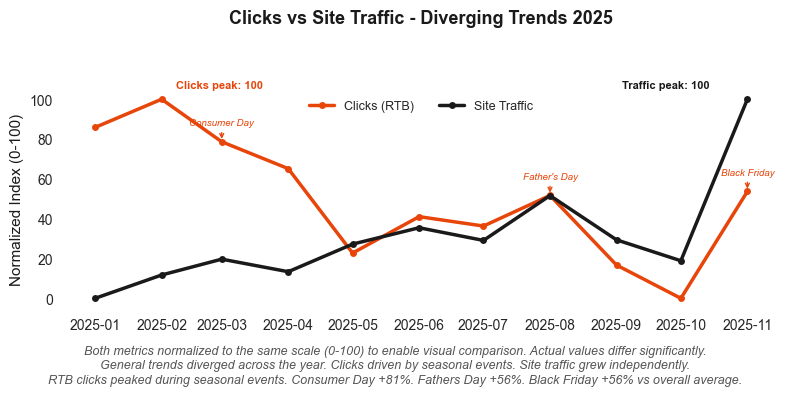

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# aggregating by month
df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby('month').agg(
    clicks=('clicks', 'mean'),
    total_tags=('total_tags', 'mean')
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

# normalizing both from 0 to 100
clicks_norm = (monthly['clicks'] - monthly['clicks'].min()) / (monthly['clicks'].max() - monthly['clicks'].min()) * 100
tags_norm = (monthly['total_tags'] - monthly['total_tags'].min()) / (monthly['total_tags'].max() - monthly['total_tags'].min()) * 100

fig, ax = plt.subplots(figsize=(8, 4))

# plotting both lines
ax.plot(monthly['month_dt'], clicks_norm,
        color='#E8450A', linewidth=2.5,
        marker='o', markersize=5, label='Clicks (RTB)')

ax.plot(monthly['month_dt'], tags_norm,
        color='#1A1A1A', linewidth=2.5,
        marker='o', markersize=5, label='Site Traffic')

# clean white background no grid
ax.set_facecolor('#FFFFFF')
fig.patch.set_facecolor('#FFFFFF')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# axis labels
ax.set_ylabel('Normalized Index (0-100)', color='#1A1A1A')
ax.set_xlabel('')

# legend above title
ax.legend(loc='upper center',
          bbox_to_anchor=(0.5, 1.0),
          ncol=2,
          fontsize=9,
          framealpha=0,
          edgecolor='none')

# title updated
ax.set_title('Clicks vs Site Traffic - Diverging Trends 2025',
             fontsize=13, fontweight='bold', color='#1A1A1A',
             pad=35, y=1.08)

# clicks peak annotation
clicks_max_idx = clicks_norm.idxmax()
ax.annotate(f'Clicks peak: {clicks_norm[clicks_max_idx]:.0f}',
            xy=(monthly['month_dt'][clicks_max_idx], clicks_norm[clicks_max_idx]),
            xytext=(10, 8), textcoords='offset points',
            ha='left', fontsize=8, color='#E8450A', fontweight='bold')

# traffic peak annotation
tags_max_idx = tags_norm.idxmax()
ax.annotate(f'Traffic peak: {tags_norm[tags_max_idx]:.0f}',
            xy=(monthly['month_dt'][tags_max_idx], tags_norm[tags_max_idx]),
            xytext=(-90, 8), textcoords='offset points',
            ha='left', fontsize=8, color='#1A1A1A', fontweight='bold')

# seasonal events annotations
events_to_annotate = {
    'Consumer Day': '2025-03',
    "Father's Day": '2025-08',
    'Black Friday': '2025-11'
}

for event_name, month_str in events_to_annotate.items():
    event_idx = monthly[monthly['month'] == month_str].index[0]
    ax.annotate(event_name,
                xy=(monthly['month_dt'][event_idx], clicks_norm[event_idx]),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=7, color='#E8450A',
                fontstyle='italic',
                arrowprops=dict(arrowstyle='->', color='#E8450A', lw=1))

# footer
fig.text(0.5, 0.01,
         'Both metrics normalized to the same scale (0-100) to enable visual comparison. Actual values differ significantly.\n'
         'General trends diverged across the year. Clicks driven by seasonal events. Site traffic grew independently.\n'
         'RTB clicks peaked during seasonal events. Consumer Day +81%. Fathers Day +56%. Black Friday +56% vs overall average.',
         ha='center', fontsize=9, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('clicks_vs_tags.png', dpi=150, bbox_inches='tight',
            facecolor='#FFFFFF')
plt.show()


In [108]:
# checking if seasonal events impacted RTB clicks
events = {
    'Consumer Day': ('2025-03-05', '2025-03-14'),
    "Father's Day": ('2025-08-05', '2025-08-09'),
    'Black Friday': ('2025-11-26', '2025-11-30')
}

print("Average daily clicks during seasonal events vs overall average:\n")
overall_avg = df['clicks'].mean()
print(f"Overall daily average: {overall_avg:,.0f} clicks\n")

for event, (start, end) in events.items():
    event_avg = df[(df['date'] >= start) & (df['date'] <= end)]['clicks'].mean()
    diff = ((event_avg - overall_avg) / overall_avg) * 100
    print(f"{event}: {event_avg:,.0f} clicks ({diff:+.1f}% vs overall average)")


Average daily clicks during seasonal events vs overall average:

Overall daily average: 19,978 clicks

Consumer Day: 36,188 clicks (+81.1% vs overall average)
Father's Day: 31,124 clicks (+55.8% vs overall average)
Black Friday: 31,166 clicks (+56.0% vs overall average)


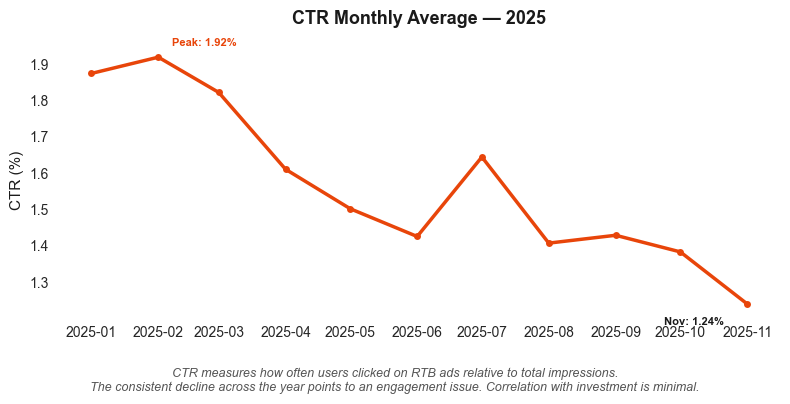

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

# aggregating CTR by month
df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby('month').agg(
    ctr=('ctr', 'mean')
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(8, 4))

# plotting CTR line
ax.plot(monthly['month_dt'], monthly['ctr'],
        color='#E8450A', linewidth=2.5,
        marker='o', markersize=5, label='CTR (%)')

# clean white background no grid
ax.set_facecolor('#FFFFFF')
fig.patch.set_facecolor('#FFFFFF')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# axis labels
ax.set_ylabel('CTR (%)', color='#1A1A1A')
ax.set_xlabel('')

# title
ax.set_title('CTR Monthly Average — 2025',
             fontsize=13, fontweight='bold', color='#1A1A1A', pad=15)

# peak annotation
ctr_max_idx = monthly['ctr'].idxmax()
ax.annotate(f'Peak: {monthly["ctr"][ctr_max_idx]:.2f}%',
            xy=(monthly['month_dt'][ctr_max_idx], monthly['ctr'][ctr_max_idx]),
            xytext=(10, 8), textcoords='offset points',
            ha='left', fontsize=8, color='#E8450A', fontweight='bold')

# last point annotation
last_idx = len(monthly) - 1
ax.annotate(f'Nov: {monthly["ctr"][last_idx]:.2f}%',
            xy=(monthly['month_dt'][last_idx], monthly['ctr'][last_idx]),
            xytext=(-60, -15), textcoords='offset points',
            ha='left', fontsize=8, color='#1A1A1A', fontweight='bold')

# footer
fig.text(0.5, 0.01,
         'CTR measures how often users clicked on RTB ads relative to total impressions.\n'
         'The consistent decline across the year points to an engagement issue. Correlation with investment is minimal.',
         ha='center', fontsize=9, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('ctr_over_time.png', dpi=150, bbox_inches='tight',
            facecolor='#FFFFFF')
plt.show()




In [114]:
# checking July CTR spike
july = df[df['date'].dt.month == 7]
print(f"July avg CTR: {july['ctr'].mean():.2f}%")
print(f"July avg cost: R$ {july['cost'].mean():.2f}")
print(f"July avg impressions: {july['imps'].mean():,.0f}")


July avg CTR: 1.64%
July avg cost: R$ 2789.86
July avg impressions: 1,086,635


In [115]:
events = {
    'Consumer Day': ('2025-03-05', '2025-03-14'),
    "Father's Day": ('2025-08-05', '2025-08-09'),
    'Black Friday': ('2025-11-26', '2025-11-30')
}

print("Average daily RTB conversions during seasonal events vs overall average:\n")
overall_avg = df['rtb_conversions'].mean()
print(f"Overall daily average: {overall_avg:,.0f} conversions\n")

for event, (start, end) in events.items():
    event_avg = df[(df['date'] >= start) & (df['date'] <= end)]['rtb_conversions'].mean()
    diff = ((event_avg - overall_avg) / overall_avg) * 100
    print(f"{event}: {event_avg:,.0f} conversions ({diff:+.1f}% vs overall average)")



Average daily RTB conversions during seasonal events vs overall average:

Overall daily average: 162 conversions

Consumer Day: 339 conversions (+108.6% vs overall average)
Father's Day: 287 conversions (+76.5% vs overall average)
Black Friday: 291 conversions (+79.0% vs overall average)


In [14]:
# dropping the row with unparseable date
df = df.dropna(subset=['date'])

# sorting by date ascending for the analysis
df = df.sort_values('date').reset_index(drop=True)

# renaming columns to make them easier to work with
df.columns = [
    'date', 'imps', 'clicks', 'ctr', 'cost',
    'cpc', 'rtb_conversions', 'cr', 'roas',
    'rtb_conversion_value', 'aov', 
    'total_conversions', 'share', 'total_tags'
]

print("All good! After treatment:", df.shape)
df.head()




All good! After treatment: (334, 14)


,date,imps,clicks,ctr,cost,cpc,rtb_conversions,cr,roas,rtb_conversion_value,aov,total_conversions,share,total_tags
0,2025-01-01,508660,11795,NaN,1047.64,NaN,59,NaN,NaN,17112.95,NaN,4752,NaN,3709976
1,2025-01-02,1995577,39905,NaN,3450.54,NaN,194,NaN,NaN,48121.23,NaN,12328,NaN,7720396
2,2025-01-03,1488615,30524,NaN,3152.22,NaN,257,NaN,NaN,66784.53,NaN,16720,NaN,9644810
3,2025-01-04,1343505,23533,NaN,3249.06,NaN,223,NaN,NaN,61855.77,NaN,18739,NaN,10380340
4,2025-01-05,1326203,25071,NaN,3156.36,NaN,193,NaN,NaN,52160.38,NaN,17039,NaN,9424658


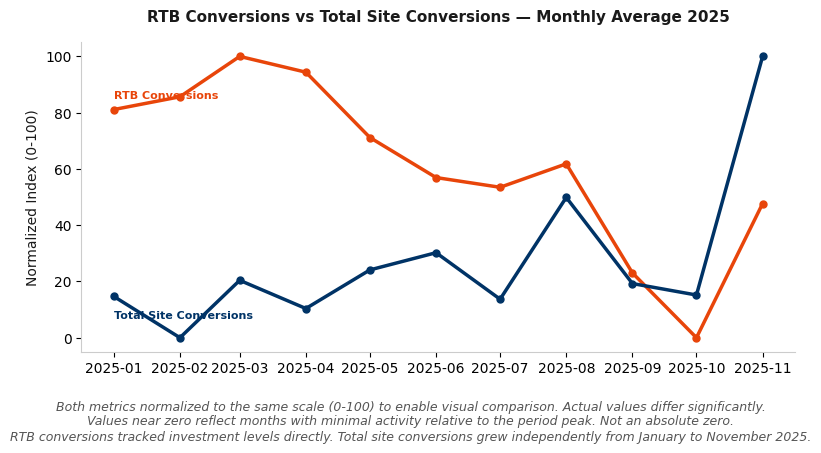

In [135]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')

# aggregating by month
df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby('month').agg(
    rtb_conversions=('rtb_conversions', 'mean'),
    total_conversions=('total_conversions', 'mean')
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

# normalizing both from 0 to 100
rtb_norm = (monthly['rtb_conversions'] - monthly['rtb_conversions'].min()) / (monthly['rtb_conversions'].max() - monthly['rtb_conversions'].min()) * 100
total_norm = (monthly['total_conversions'] - monthly['total_conversions'].min()) / (monthly['total_conversions'].max() - monthly['total_conversions'].min()) * 100

fig, ax = plt.subplots(figsize=(8, 4.5))

# plotting both lines
ax.plot(monthly['month_dt'], rtb_norm,
        color='#E8450A', linewidth=2.5,
        marker='o', markersize=5)

ax.plot(monthly['month_dt'], total_norm,
        color='#003366', linewidth=2.5,
        marker='o', markersize=5)

# labeling lines at start
ax.text(monthly['month_dt'].iloc[0], rtb_norm.iloc[0] + 4,
        'RTB Conversions', color='#E8450A',
        fontsize=8, fontweight='bold', ha='left')

ax.text(monthly['month_dt'].iloc[0], total_norm.iloc[0] - 8,
        'Total Site Conversions', color='#003366',
        fontsize=8, fontweight='bold', ha='left')

# clean white background no grid
ax.set_facecolor('#FFFFFF')
fig.patch.set_facecolor('#FFFFFF')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# axis labels
ax.set_ylabel('Normalized Index (0-100)', color='#1A1A1A')
ax.set_xlabel('')

# title
ax.set_title('RTB Conversions vs Total Site Conversions — Monthly Average 2025',
             fontsize=11, fontweight='bold', color='#1A1A1A', pad=15)

# footer
fig.text(0.5, 0.01,
         'Both metrics normalized to the same scale (0-100) to enable visual comparison. Actual values differ significantly.\n'
         'Values near zero reflect months with minimal activity relative to the period peak. Not an absolute zero.\n'
         'RTB conversions tracked investment levels directly. Total site conversions grew independently from January to November 2025.',
         ha='center', fontsize=9, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig('conversions_monthly.png', dpi=150, bbox_inches='tight',
            facecolor='#FFFFFF')
plt.show()



In [132]:
oct_data = df[df['date'].dt.month == 10]
print(f"October RTB conversions avg: {oct_data['rtb_conversions'].mean():.0f}")
print(f"October total conversions avg: {oct_data['total_conversions'].mean():.0f}")
print(f"October investment avg: R$ {oct_data['cost'].mean():.2f}")



October RTB conversions avg: 85
October total conversions avg: 15872
October investment avg: R$ 1305.95


In [126]:
jan = df[df['date'].dt.month == 1]['ctr'].mean()
nov = df[df['date'].dt.month == 11]['ctr'].mean()
print(f"January CTR: {jan:.2f}%")
print(f"November CTR: {nov:.2f}%")

January CTR: 1.87%
November CTR: 1.24%


In [127]:
jan = df[df['date'].dt.month == 1]['aov'].mean()
nov = df[df['date'].dt.month == 11]['aov'].mean()
print(f"January AOV: R$ {jan:.2f}")
print(f"November AOV: R$ {nov:.2f}")



January AOV: R$ 276.78
November AOV: R$ 315.59


In [136]:
jan_share = df[df['date'].dt.month == 1]['share'].mean()
nov_share = df[df['date'].dt.month == 11]['share'].mean()
diff = ((nov_share - jan_share) / jan_share) * 100
print(f"January share: {jan_share:.2f}%")
print(f"November share: {nov_share:.2f}%")
print(f"Variation: {diff:.1f}%")

January share: 1.18%
November share: 0.59%
Variation: -49.8%


In [137]:
# weekly pattern analysis
df['day_of_week'] = df['date'].dt.day_name()

weekly = df.groupby('day_of_week').agg(
    impressions=('imps', 'mean'),
    clicks=('clicks', 'mean'),
    rtb_conversions=('rtb_conversions', 'mean'),
    total_tags=('total_tags', 'mean'),
    ctr=('ctr', 'mean')
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

print(weekly.round(2))



             impressions   clicks  rtb_conversions  total_tags  ctr
day_of_week                                                        
Monday         972826.79 15314.11            90.47  9850455.49 1.58
Tuesday       1393035.98 21297.87           162.26 12539171.96 1.55
Wednesday     1437591.50 22022.75           188.40 13298334.75 1.57
Thursday      1433957.25 22047.58           194.92 13289148.44 1.56
Friday        1441757.88 22414.65           194.73 12956412.06 1.57
Saturday      1388444.69 20882.90           188.29 12383375.31 1.54
Sunday         973073.62 15795.31           115.90 10275059.92 1.60


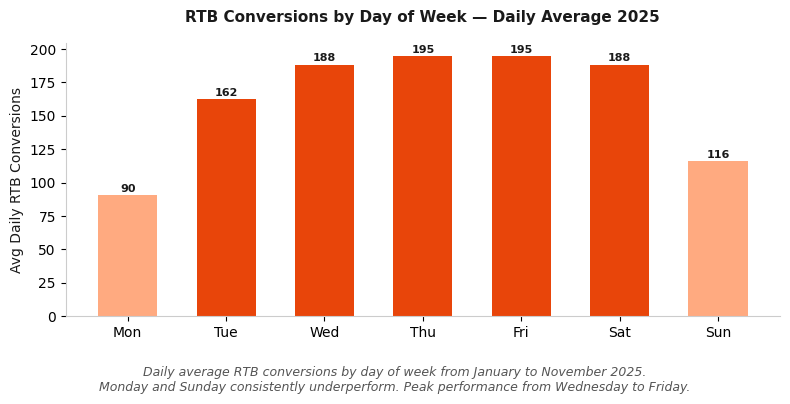

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')

# aggregating by day of week
df['day_of_week'] = df['date'].dt.day_name()

weekly = df.groupby('day_of_week').agg(
    rtb_conversions=('rtb_conversions', 'mean')
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
values = weekly['rtb_conversions'].values

# only Monday and Sunday as weak days
colors = ['#FFAA80', '#E8450A', '#E8450A', '#E8450A', '#E8450A', '#E8450A', '#FFAA80']

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(days, values, color=colors, width=0.6)

# value labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=8,
            color='#1A1A1A', fontweight='bold')

# clean white background no grid
ax.set_facecolor('#FFFFFF')
fig.patch.set_facecolor('#FFFFFF')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# axis labels
ax.set_ylabel('Avg Daily RTB Conversions', color='#1A1A1A')
ax.set_xlabel('')

# title
ax.set_title('RTB Conversions by Day of Week — Daily Average 2025',
             fontsize=11, fontweight='bold', color='#1A1A1A', pad=15)

# footer
fig.text(0.5, 0.01,
         'Daily average RTB conversions by day of week from January to November 2025.\n'
         'Monday and Sunday consistently underperform. Peak performance from Wednesday to Friday.',
         ha='center', fontsize=9, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('weekly_pattern.png', dpi=150, bbox_inches='tight',
            facecolor='#FFFFFF')
plt.show()

**The takeaway:**

**Seasonality:** Monday and Sunday are the weakest days across every metric. Wednesday 
to Friday are the strongest. The Monday drop is bigger for RTB conversions (-53.6%) 
than for site tags (-25.9%), so slow days on the site hurt the channel more.

Three major seasonal events stand out in the data:
- **Black Friday / Cyber Week** (late November) — the biggest event, with peaks across all metrics
- **Father's Day week** (early August) — second-biggest event, strong on site conversions and tags
- **Consumer Day window** (March 5-14) — third event, particularly strong on RTB conversions

**Stability:** ROAS was the most stable metric of the year (CV 25.7%, the lowest of 
all). It varied only -2.2% from Q1 to Q4, even with investment falling by more than 
half. Cost and RTB conversions were the most volatile. The cause of the investment 
reduction isn't in the data, but the channel itself didn't show instability — ROAS 
stayed in a healthy range throughout.

**Other metrics worth mentioning:**

CTR dropped 29.8% during the year. Correlation with investment is weak (0.36), so 
it's not the main cause. The drop was gradual from January to June and sharper in 
November. Without data on creatives, audience or inventory, the exact cause can't 
be confirmed.

AOV stayed stable around R$ 282-309 (+2.9% Q1 to Q4). Conversion profile didn't change.

The strongest finding came from these correlations:

| Relation | Correlation |
|---|---|
| Investment ↔ RTB Conversions | +0.86 |
| Investment ↔ ROAS | -0.47 |
| Investment ↔ CTR | +0.36 |
| Site Tags ↔ RTB Conversions | -0.28 |

The channel is predictable: more investment brings more conversions, but with lower 
marginal efficiency. ROAS doesn't depend on site traffic — it depends on how the 
platform allocates budget. The RTB volume drop during the year came from reduced 
investment, not from a performance issue with the channel.